# 😊 Klasifikasi Emosi Wajah — GLCM + Logistic Regression
### Versi Lengkap dengan Visualisasi Mendalam & Preprocessing Gambar Mentah

---

**Dataset:** Subset FER2013 (48×48 pixel, grayscale) — `angry, happy, sad, surprise`  
**Fitur:** Gray-Level Co-occurrence Matrix (GLCM) → Contrast, Homogeneity, Energy, Correlation  
**Model:** Logistic Regression  

---

## Alur Kerja Notebook

```
BAGIAN 0  ──  Setup & Import Library
BAGIAN 1  ──  Load Dataset + Preprocessing + Simpan Hasil ke Disk
              └── Visualisasi: Before/After + Histogram Pixel
BAGIAN 2  ──  Ekstraksi Fitur GLCM
              └── Visualisasi: Heatmap + Angka + Interpretasi Fitur
BAGIAN 3  ──  Pemodelan Logistic Regression
              └── Visualisasi: Decision Boundary + Bobot Model
BAGIAN 4  ──  Evaluasi Lengkap (6 Skenario)
BAGIAN 5  ──  Preprocessing Gambar Mentah (Foto Sendiri)
```

---
# BAGIAN 0 — Setup & Import Library

## Penjelasan Library

| Library | Fungsi Spesifik dalam Proyek Ini |
|---|---|
| `os`, `glob`, `pathlib` | Navigasi folder, pencarian file gambar secara rekursif |
| `pickle` | **Menyimpan/memuat** objek Python (array fitur, model, scaler) ke disk |
| `numpy` | Komputasi numerik array pixel, statistik, operasi vektor |
| `matplotlib` | Semua plot: grid gambar, histogram, heatmap, scatter plot |
| `seaborn` | Heatmap confusion matrix, distribusi yang lebih indah |
| `PIL (Pillow)` | Buka/simpan gambar, konversi mode warna (RGB→Grayscale) |
| `cv2 (OpenCV)` | Deteksi wajah dari gambar mentah (Haar Cascade), operasi morfologi |
| `skimage.feature` | Fungsi inti: `graycomatrix()` dan `graycoprops()` |
| `sklearn` | Model, scaler, metrik evaluasi, PCA, t-SNE, LabelEncoder |

> **Mengapa `pickle`?** Setelah fitur diekstrak (proses berat), kita simpan hasilnya ke disk. Jika notebook di-restart, kita bisa langsung memuat ulang tanpa harus menghitung ulang dari awal.

In [1]:
# ================================================================
#  CELL 0 — Import Semua Library
# ================================================================

import os
import glob
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from PIL import Image
import cv2                                      # OpenCV untuk deteksi wajah

from skimage.feature import graycomatrix, graycoprops

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# --- Konfigurasi tampilan global ---
plt.rcParams.update({
    'figure.dpi'    : 120,
    'font.size'     : 11,
    'axes.titlesize': 12,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


---
# BAGIAN 1 — Persiapan & Preprocessing Dataset

## 1.1 Konfigurasi Path & Folder Output

Kita buat folder khusus `outputs/` untuk menyimpan semua hasil preprocessing dan model.  
Ini penting agar eksperimen bisa di-**resume** tanpa mengulang dari awal.

### Strategi Penyimpanan:
```
outputs/
├── preprocessed/          ← Gambar grayscale hasil preprocessing (.npy)
│   ├── train_raw.npy      ← Array gambar asli (uint8, 0-255)
│   ├── train_norm.npy     ← Array gambar ternormalisasi (float32, 0-1)
│   ├── train_labels.pkl   ← List label kelas
│   ├── test_raw.npy
│   ├── test_norm.npy
│   └── test_labels.pkl
├── features/              ← Fitur GLCM per skenario (.pkl)
├── models/                ← Model terlatih (.pkl)
└── figures/               ← Semua gambar visualisasi (.png)
```

In [2]:
# ================================================================
#  CELL 1.1 — Konfigurasi Konstanta & Buat Folder Output
# ================================================================

# --- PATH DATASET (sesuaikan dengan lokasi lokal Anda) ---
BASE_DIR  = 'dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# --- KELAS EMOSI ---
CLASSES = ['angry', 'happy', 'sad', 'surprise']
COLORS  = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']  # Warna per kelas

# --- PARAMETER PREPROCESSING ---
IMG_SIZE = (48, 48)

# --- PARAMETER GLCM ---
DISTANCES      = [1]
ANGLES         = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_LABELS   = ['0°', '45°', '90°', '135°']
LEVELS_TO_TEST = [8, 16, 32]
GLCM_PROPS     = ['contrast', 'homogeneity', 'energy', 'correlation']

# --- FOLDER OUTPUT ---
OUT_ROOT    = Path('outputs')
OUT_PREPROC = OUT_ROOT / 'preprocessed'
OUT_FEAT    = OUT_ROOT / 'features'
OUT_MODELS  = OUT_ROOT / 'models'
OUT_FIGS    = OUT_ROOT / 'figures'

for folder in [OUT_PREPROC, OUT_FEAT, OUT_MODELS, OUT_FIGS]:
    folder.mkdir(parents=True, exist_ok=True)

print("📁 Folder output berhasil dibuat:")
for folder in [OUT_PREPROC, OUT_FEAT, OUT_MODELS, OUT_FIGS]:
    print(f"   {folder}/")

# Verifikasi folder dataset
print("\n📂 Verifikasi Dataset:")
for folder in [TRAIN_DIR, TEST_DIR]:
    status = "✅" if os.path.exists(folder) else "❌ TIDAK DITEMUKAN!"
    print(f"   {status}  {folder}")

📁 Folder output berhasil dibuat:
   outputs\preprocessed/
   outputs\features/
   outputs\models/
   outputs\figures/

📂 Verifikasi Dataset:
   ✅  dataset\train
   ✅  dataset\test


## 1.2 Fungsi Load + Preprocessing + Simpan ke Disk

### Tahap Preprocessing yang Dilakukan:

| Tahap | Operasi | Alasan |
|---|---|---|
| 1 | Buka gambar dengan PIL | Format universal untuk berbagai tipe file |
| 2 | Konversi ke Grayscale `'L'` | GLCM butuh gambar 1-channel (2D array) |
| 3 | Resize ke 48×48 px (LANCZOS) | Seragamkan dimensi; LANCZOS = kualitas terbaik |
| 4 | Simpan versi `uint8` [0–255] | Untuk visualisasi dan referensi asli |
| 5 | Normalisasi `/ 255.0` → float32 | Agar skala pixel seragam [0,1] untuk GLCM |

### Mengapa Menyimpan ke `.npy` dan `.pkl`?
- **`.npy`** (NumPy format): Format biner tercepat untuk array numerik. Load ulang hampir instan.
- **`.pkl`** (Pickle): Untuk menyimpan objek Python apapun (list, dict, model sklearn).

```python
# Simpan
np.save('file.npy', array)        # Array NumPy
pickle.dump(obj, open('f.pkl','wb'))  # Objek Python apapun

# Muat ulang
array = np.load('file.npy')
obj   = pickle.load(open('f.pkl','rb'))
```

In [3]:
# ================================================================
#  CELL 1.2 — Fungsi Load, Preprocess, & Simpan Dataset
# ================================================================

def load_and_preprocess(data_dir, split_name, img_size=IMG_SIZE,
                         classes=CLASSES, force_reload=False):
    """
    Memuat, memproses, dan menyimpan dataset ke disk.
    Jika file sudah ada dan force_reload=False, langsung muat dari cache.

    Args:
        data_dir     : Path folder (train atau test)
        split_name   : 'train' atau 'test' (untuk nama file cache)
        img_size     : Tuple target ukuran gambar (w, h)
        classes      : List nama kelas/subfolder
        force_reload : Paksa reload meskipun cache ada

    Returns:
        images_raw  : List array uint8 [0-255] — gambar asli
        images_norm : List array float32 [0-1] — gambar ternormalisasi
        labels      : List string label kelas
    """
    # --- Path file cache ---
    path_raw    = OUT_PREPROC / f'{split_name}_raw.npy'
    path_norm   = OUT_PREPROC / f'{split_name}_norm.npy'
    path_labels = OUT_PREPROC / f'{split_name}_labels.pkl'

    # --- Cek apakah cache sudah ada ---
    if not force_reload and path_raw.exists():
        print(f"  📦 Memuat '{split_name}' dari cache...")
        images_raw  = list(np.load(str(path_raw),  allow_pickle=True))
        images_norm = list(np.load(str(path_norm), allow_pickle=True))
        with open(path_labels, 'rb') as f:
            labels = pickle.load(f)
        print(f"     ✅ Berhasil: {len(labels)} gambar dimuat dari cache.")
        return images_raw, images_norm, labels

    # --- Proses dari awal ---
    print(f"  🔄 Memproses '{split_name}' dari folder...")
    images_raw, images_norm, labels = [], [], []

    for cls in classes:
        folder_path = os.path.join(data_dir, cls)
        img_paths   = (glob.glob(os.path.join(folder_path, '*.jpg')) +
                       glob.glob(os.path.join(folder_path, '*.png')))
        print(f"     [{cls:>10}]: {len(img_paths)} gambar")

        for img_path in img_paths:
            try:
                # 1. Buka & konversi ke grayscale
                img = Image.open(img_path).convert('L')
                # 2. Resize dengan interpolasi LANCZOS (anti-aliasing terbaik)
                img = img.resize(img_size, Image.LANCZOS)
                # 3. Simpan versi asli (integer 0-255)
                arr_raw = np.array(img, dtype=np.uint8)
                # 4. Normalisasi ke [0.0, 1.0]
                arr_norm = arr_raw.astype(np.float32) / 255.0

                images_raw.append(arr_raw)
                images_norm.append(arr_norm)
                labels.append(cls)
            except Exception as e:
                print(f"     ⚠️  Skip: {img_path} ({e})")

    # --- Simpan ke disk ---
    np.save(str(path_raw),  np.array(images_raw,  dtype=object))
    np.save(str(path_norm), np.array(images_norm, dtype=object))
    with open(path_labels, 'wb') as f:
        pickle.dump(labels, f)

    print(f"     💾 Tersimpan ke '{OUT_PREPROC}/' ({len(labels)} gambar)")
    return images_raw, images_norm, labels


# --- Jalankan untuk train & test ---
print("📂 LOADING DATASET:")
train_raw, train_norm, train_labels = load_and_preprocess(TRAIN_DIR, 'train')
test_raw,  test_norm,  test_labels  = load_and_preprocess(TEST_DIR,  'test')

print(f"\n📊 Ringkasan:")
print(f"   Training : {len(train_labels)} gambar")
print(f"   Test     : {len(test_labels)} gambar")
print(f"   Shape    : {train_raw[0].shape} per gambar")

📂 LOADING DATASET:
  🔄 Memproses 'train' dari folder...
     [     angry]: 3100 gambar
     [     happy]: 3100 gambar
     [       sad]: 3100 gambar
     [  surprise]: 3100 gambar
     💾 Tersimpan ke 'outputs\preprocessed/' (12400 gambar)
  🔄 Memproses 'test' dari folder...
     [     angry]: 775 gambar
     [     happy]: 775 gambar
     [       sad]: 775 gambar
     [  surprise]: 775 gambar
     💾 Tersimpan ke 'outputs\preprocessed/' (3100 gambar)

📊 Ringkasan:
   Training : 12400 gambar
   Test     : 3100 gambar
   Shape    : (48, 48) per gambar


## 1.3 Visualisasi Before vs. After + Histogram Pixel

Kita visualisasikan dua hal sekaligus:
1. **Grid gambar** Before/After untuk tiap kelas
2. **Histogram distribusi pixel** — ini yang membuat perbedaan normalisasi terlihat secara kuantitatif

### Mengapa Histogram Penting?
- **Before (uint8)**: Histogram memperlihatkan distribusi nilai pixel di rentang 0–255
- **After (float32)**: Distribusi yang sama, tetapi nilai sumbu X menjadi 0.0–1.0
- Bentuk histogram **tidak berubah** (itu artinya normalisasi linear memang hanya mengubah skala, bukan distribusi)
- Kita bisa melihat apakah gambar cenderung **gelap** (histogram menumpuk di kiri), **terang** (kanan), atau **seimbang**

### Sintaks Penting — `ax.hist()`:
```python
ax.hist(
    img.ravel(),   # .ravel() → ubah array 2D (48,48) jadi 1D (2304,) untuk dihitung frekuensinya
    bins=64,       # Jumlah 'ember' (bucket) untuk mengelompokkan nilai pixel
    range=(0,255), # Batasan nilai sumbu X
    color='steelblue',
    alpha=0.7,
    density=True   # Normalisasi histogram agar area = 1 (probabilitas, bukan jumlah)
)
```

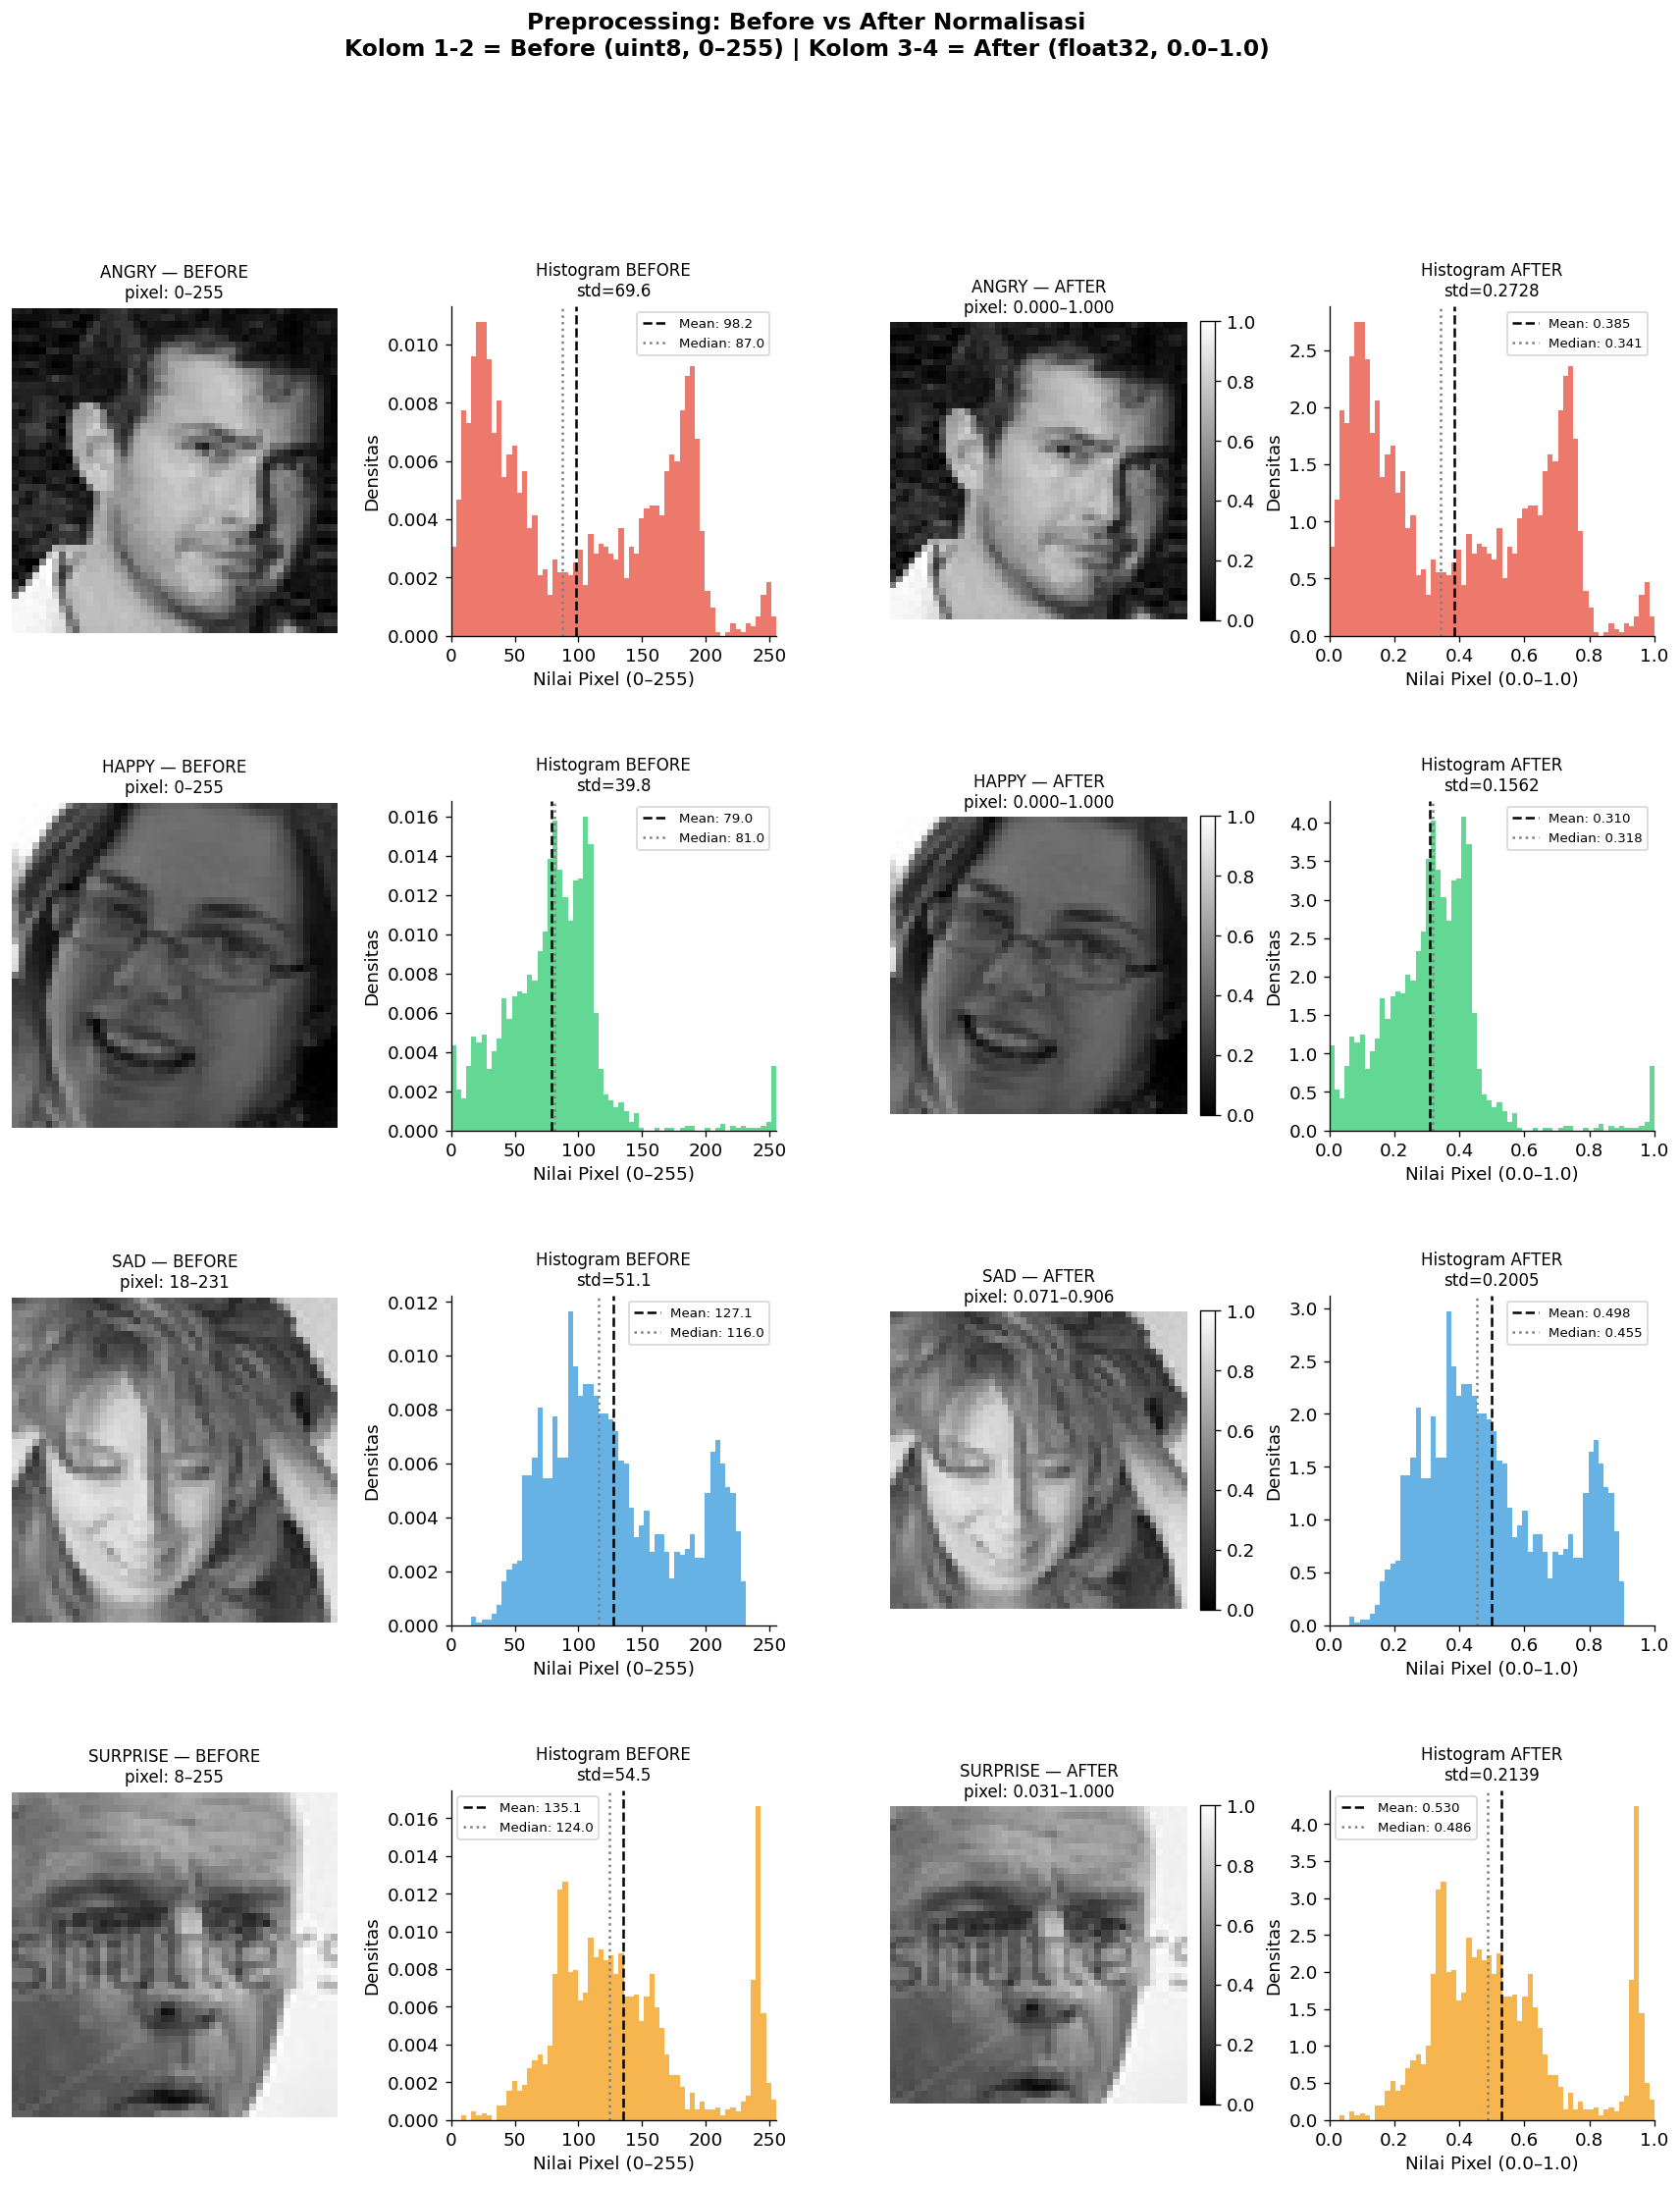

💾 Gambar disimpan: outputs\figures\01_before_after_histogram.png


In [4]:
# ================================================================
#  CELL 1.3 — Visualisasi Before/After + Histogram Pixel
# ================================================================

def get_sample_per_class(raw_list, norm_list, label_list, classes=CLASSES):
    """Ambil 1 contoh gambar untuk setiap kelas."""
    return {
        cls: {'raw': raw_list[label_list.index(cls)],
              'norm': norm_list[label_list.index(cls)]}
        for cls in classes
    }

samples = get_sample_per_class(train_raw, train_norm, train_labels)

# Layout: 4 kelas × (gambar_before | histogram_before | gambar_after | histogram_after)
# = 4 baris × 4 kolom
fig = plt.figure(figsize=(18, 5 * len(CLASSES)))
fig.suptitle('Preprocessing: Before vs After Normalisasi\n'
             'Kolom 1-2 = Before (uint8, 0–255) | Kolom 3-4 = After (float32, 0.0–1.0)',
             fontsize=14, fontweight='bold', y=1.005)

gs = gridspec.GridSpec(len(CLASSES), 4, figure=fig, hspace=0.5, wspace=0.35)

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_raw  = samples[cls]['raw']
    img_norm = samples[cls]['norm']

    # ---- Kolom 0: Gambar BEFORE ----
    ax_img_b = fig.add_subplot(gs[row, 0])
    ax_img_b.imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    ax_img_b.set_title(f'{cls.upper()} — BEFORE\npixel: {img_raw.min()}–{img_raw.max()}',
                       fontsize=10)
    ax_img_b.axis('off')
    # Border berwarna per kelas
    for spine in ax_img_b.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)

    # ---- Kolom 1: Histogram BEFORE ----
    ax_hist_b = fig.add_subplot(gs[row, 1])
    n, bins, patches = ax_hist_b.hist(
        img_raw.ravel(),     # .ravel() → flatten 2D→1D
        bins=64,
        range=(0, 255),
        color=color,
        alpha=0.75,
        density=True,        # Normalisasi agar area total = 1.0
        edgecolor='none'
    )
    # Tambahkan garis mean dan median
    ax_hist_b.axvline(img_raw.mean(),   color='black', lw=1.5, ls='--', label=f'Mean: {img_raw.mean():.1f}')
    ax_hist_b.axvline(np.median(img_raw), color='gray',  lw=1.5, ls=':',  label=f'Median: {np.median(img_raw):.1f}')
    ax_hist_b.set_title(f'Histogram BEFORE\nstd={img_raw.std():.1f}', fontsize=10)
    ax_hist_b.set_xlabel('Nilai Pixel (0–255)')
    ax_hist_b.set_ylabel('Densitas')
    ax_hist_b.legend(fontsize=8)
    ax_hist_b.set_xlim(0, 255)

    # ---- Kolom 2: Gambar AFTER ----
    ax_img_a = fig.add_subplot(gs[row, 2])
    im = ax_img_a.imshow(img_norm, cmap='gray', vmin=0.0, vmax=1.0)
    ax_img_a.set_title(f'{cls.upper()} — AFTER\npixel: {img_norm.min():.3f}–{img_norm.max():.3f}',
                       fontsize=10)
    ax_img_a.axis('off')
    plt.colorbar(im, ax=ax_img_a, fraction=0.046, pad=0.04)
    for spine in ax_img_a.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)

    # ---- Kolom 3: Histogram AFTER ----
    ax_hist_a = fig.add_subplot(gs[row, 3])
    ax_hist_a.hist(
        img_norm.ravel(),
        bins=64,
        range=(0.0, 1.0),
        color=color,
        alpha=0.75,
        density=True,
        edgecolor='none'
    )
    ax_hist_a.axvline(img_norm.mean(),     color='black', lw=1.5, ls='--',
                      label=f'Mean: {img_norm.mean():.3f}')
    ax_hist_a.axvline(np.median(img_norm), color='gray',  lw=1.5, ls=':',
                      label=f'Median: {np.median(img_norm):.3f}')
    ax_hist_a.set_title(f'Histogram AFTER\nstd={img_norm.std():.4f}', fontsize=10)
    ax_hist_a.set_xlabel('Nilai Pixel (0.0–1.0)')
    ax_hist_a.set_ylabel('Densitas')
    ax_hist_a.legend(fontsize=8)
    ax_hist_a.set_xlim(0.0, 1.0)

plt.savefig(str(OUT_FIGS / '01_before_after_histogram.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '01_before_after_histogram.png')

## 1.4 Visualisasi Distribusi Histogram Seluruh Kelas (Overlay)

Plot berikut membandingkan **bentuk distribusi pixel** dari semua kelas secara bersamaan.  
Ini memberikan gambaran apakah ada perbedaan karakteristik kecerahan antar ekspresi emosi.

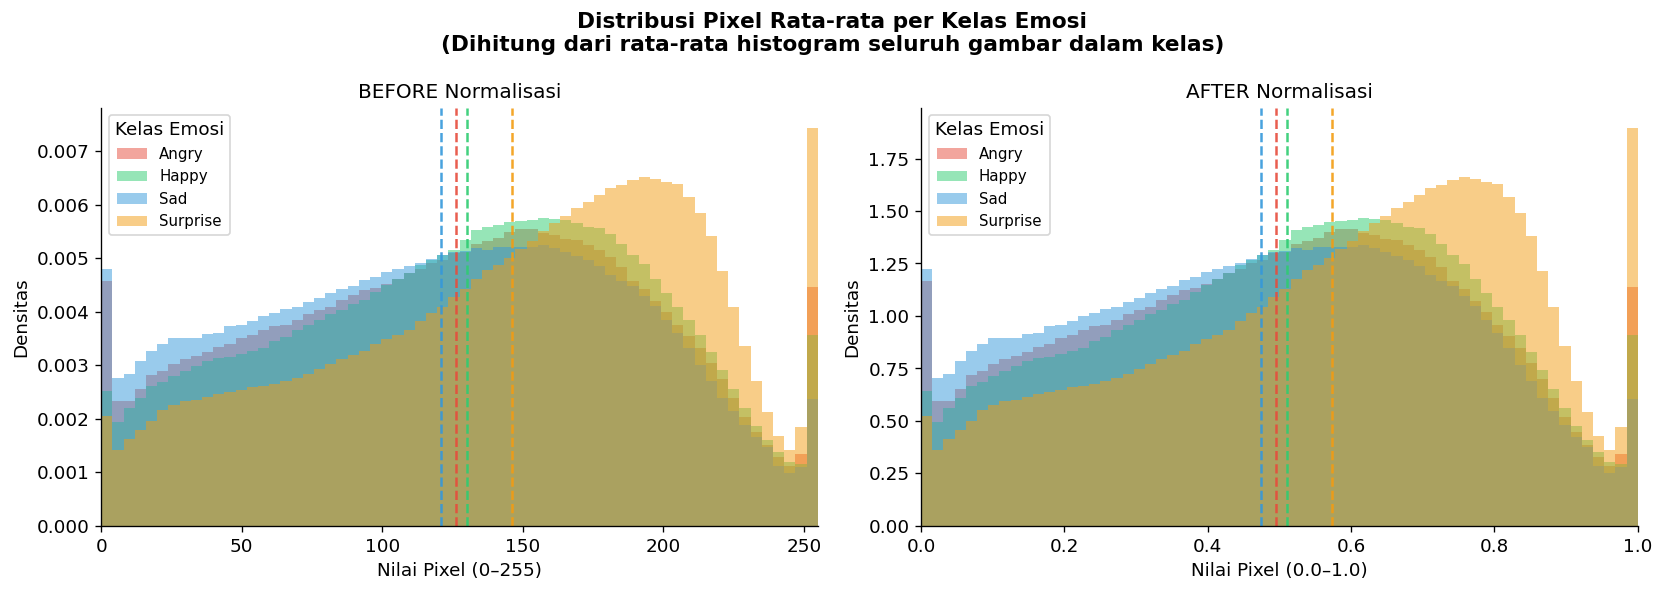

💾 Gambar disimpan: outputs\figures\02_histogram_overlay.png


In [5]:
# ================================================================
#  CELL 1.4 — Histogram Overlay Seluruh Kelas (Rata-rata)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Pixel Rata-rata per Kelas Emosi\n'
             '(Dihitung dari rata-rata histogram seluruh gambar dalam kelas)',
             fontsize=13, fontweight='bold')

bins_count = 64

for ax, (img_list, title, x_label, x_range) in zip(
    axes,
    [(train_raw,  'BEFORE Normalisasi', 'Nilai Pixel (0–255)',   (0, 255)),
     (train_norm, 'AFTER Normalisasi',  'Nilai Pixel (0.0–1.0)', (0.0, 1.0))]
):
    for cls, color in zip(CLASSES, COLORS):
        # Kumpulkan semua pixel dari gambar kelas ini
        all_pixels = np.concatenate([
            img.ravel() for img, lbl in zip(img_list, train_labels) if lbl == cls
        ])

        # Plot histogram dengan transparansi
        ax.hist(all_pixels, bins=bins_count, range=x_range,
                color=color, alpha=0.5, density=True,
                label=cls.capitalize(), edgecolor='none')

        # Tambahkan garis mean vertikal
        ax.axvline(all_pixels.mean(), color=color, lw=1.5, ls='--', alpha=0.9)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Densitas')
    ax.legend(title='Kelas Emosi', fontsize=9)
    ax.set_xlim(x_range)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '02_histogram_overlay.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '02_histogram_overlay.png')

---
# BAGIAN 2 — Representasi Fitur: GLCM

## 2.1 Konsep & Bedah Sintaks GLCM

### Bagaimana GLCM Dibangun?

```
Gambar asli pixel:              Setelah kuantisasi 4-level:
 200  150  80                    3   2   1
 120   90  60        →           2   1   0
  50   40  30                    0   0   0

Untuk sudut 0° (→ kanan), d=1:
Pasangan yang ditemukan: (3,2), (2,1), (2,1), (1,0), (0,0), (0,0)

GLCM[i][j] = berapa kali pixel i bersebelahan dengan pixel j (ke kanan)
     j: 0  1  2  3
i:0 [  2  0  0  0 ]
  1 [  1  0  1  0 ]
  2 [  0  2  0  0 ]
  3 [  0  0  1  0 ]
```

### Bedah Sintaks `graycomatrix()`:

```python
glcm = graycomatrix(
    image,            # Array 2D integer [0, levels-1]
    distances = [1],  # d=1: hitung pasangan piksel yang LANGSUNG bersebelahan
    angles    = [0, np.pi/4, np.pi/2, 3*np.pi/4],  # 4 arah: →, ↘, ↓, ↙
    levels    = 16,   # L: gambar dikuantisasi ke L level → matriks L×L
    symmetric = True, # Tambahkan juga pasangan (j,i) untuk setiap (i,j)
                      # → matriks simetris, lebih stabil secara statistik
    normed    = True  # Bagi dengan total pasangan → nilai probabilitas [0,1]
)
# Output shape: (levels, levels, len(distances), len(angles))
# Contoh: (16, 16, 1, 4)

val = graycoprops(glcm, 'contrast')  # Output shape: (1, 4)
```

In [6]:
# ================================================================
#  CELL 2.1 — Fungsi Kuantisasi & Ekstraksi Fitur GLCM
# ================================================================

def quantize_image(img_norm, levels):
    """
    Mengkuantisasi gambar float [0,1] ke integer [0, levels-1].
    Contoh levels=8: pixel 0.75 → floor(0.75*8)=6 → level ke-6.
    np.clip memastikan tidak ada nilai tepat 1.0 yang menghasilkan index=levels.
    """
    return np.clip(
        np.floor(img_norm * levels).astype(np.int32), 0, levels - 1
    )


def extract_glcm_features(img_norm, levels,
                           distances=DISTANCES, angles=ANGLES,
                           props=GLCM_PROPS, aggregation='mean'):
    """
    Ekstrak vektor fitur statistik dari GLCM sebuah gambar.

    aggregation='mean'  → rata-rata 4 sudut → 4 fitur
    aggregation='concat'→ semua sudut dipisah → 16 fitur

    Returns:
        feature_vector (np.ndarray): Vektor 1D
        glcm_raw       (np.ndarray): Objek GLCM mentah (untuk visualisasi)
    """
    img_q = quantize_image(img_norm, levels)

    glcm = graycomatrix(
        img_q,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    feature_vector = []
    if aggregation == 'mean':
        for prop in props:
            feature_vector.append(graycoprops(glcm, prop).mean())
    elif aggregation == 'concat':
        for prop in props:
            feature_vector.extend(graycoprops(glcm, prop).flatten())

    return np.array(feature_vector, dtype=np.float32), glcm


# Test
feat_test, glcm_test = extract_glcm_features(train_norm[0], levels=16, aggregation='mean')
print("✅ Fungsi GLCM berjalan normal.")
print(f"   Fitur (mean, L=16): {np.round(feat_test, 4)}")
print(f"   Shape GLCM: {glcm_test.shape}  ← (16, 16, 1, 4)")

✅ Fungsi GLCM berjalan normal.
   Fitur (mean, L=16): [3.1831 0.6025 0.1629 0.9145]
   Shape GLCM: (16, 16, 1, 4)  ← (16, 16, 1, 4)


## 2.2 Visualisasi GLCM: Angka Mentah + Heatmap (Dua Analisis)

Untuk satu gambar contoh, kita sajikan matriks GLCM dalam **dua cara**:

### Analisis 1 — Tabel Angka Mentah:
- Memperlihatkan **nilai probabilitas eksak** di setiap sel matriks
- Berguna untuk memverifikasi nilai numerik dan memahami skala angkanya
- Diagonal ≈ probabilitas pixel bersebelahan dengan pixel bernilai sama

### Analisis 2 — Heatmap Warna:
- Memperlihatkan **pola distribusi** secara visual
- Warna terang = nilai tinggi (pasangan sering muncul)
- Diagonal terang = gambar homogen; off-diagonal terang = banyak transisi tajam

> **Tips membaca GLCM:** Gambar wajah manusia biasanya menunjukkan GLCM terkonsentrasi di sekitar diagonal karena area kulit dan latar belakang memiliki nilai pixel yang relatif seragam.

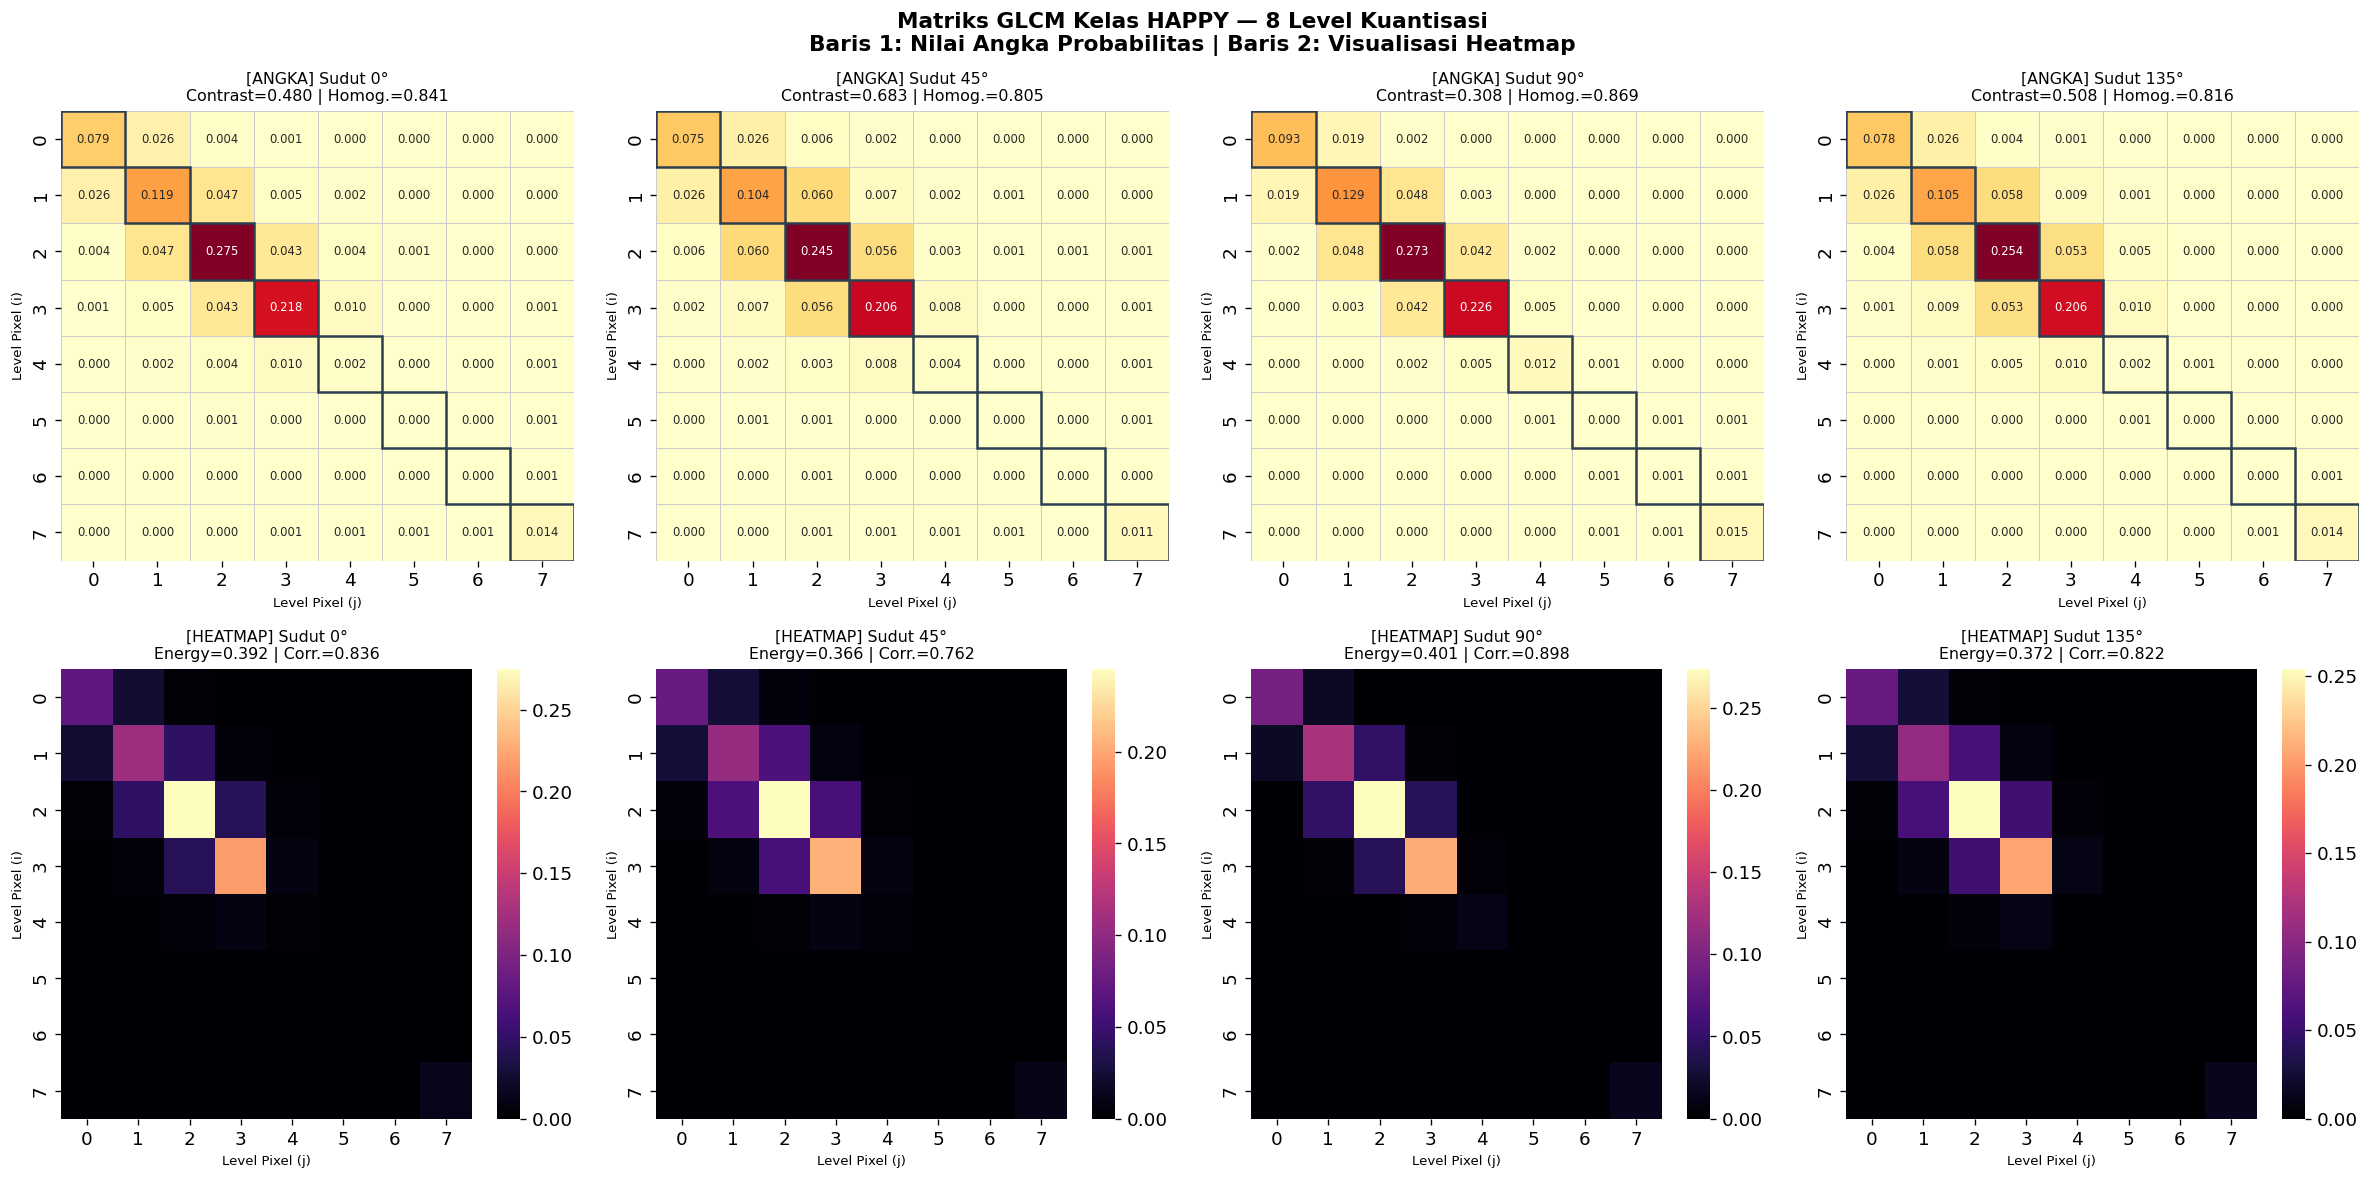

💾 Gambar disimpan: outputs\figures\03_glcm_angka_dan_heatmap.png


In [7]:
# ================================================================
#  CELL 2.2 — Matriks GLCM: Angka Mentah vs Heatmap (4 Sudut)
# ================================================================

LEVELS_VIS = 8   # Pakai 8 level agar angkanya muat di tampilan tabel

# Ambil contoh gambar 'happy'
idx_ex    = train_labels.index('happy')
img_ex    = train_norm[idx_ex]
img_ex_q  = quantize_image(img_ex, LEVELS_VIS)

glcm_ex = graycomatrix(
    img_ex_q,
    distances=[1],
    angles=ANGLES,
    levels=LEVELS_VIS,
    symmetric=True,
    normed=True
)

# Layout: 2 baris (Angka | Heatmap) × 4 kolom (sudut 0°,45°,90°,135°)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f'Matriks GLCM Kelas HAPPY — {LEVELS_VIS} Level Kuantisasi\n'
    'Baris 1: Nilai Angka Probabilitas | Baris 2: Visualisasi Heatmap',
    fontsize=13, fontweight='bold'
)

label_ticks = [str(i) for i in range(LEVELS_VIS)]

for col, (angle_idx, angle_lbl) in enumerate(zip(range(4), ANGLE_LABELS)):
    glcm_2d = glcm_ex[:, :, 0, angle_idx]   # Slice matriks 2D untuk sudut ini

    # ============================================================
    # BARIS 0: Tabel Angka Mentah
    # ============================================================
    ax_num = axes[0, col]

    # sns.heatmap dengan annot=True dan fmt='.3f → tampilkan angka di setiap sel
    # cmap='YlOrRd_r' → warna terbalik: tinggi=kuning (lebih terlihat dengan angka gelap)
    sns.heatmap(
        glcm_2d,
        ax=ax_num,
        annot=True,                    # ← Tampilkan ANGKA di setiap sel
        fmt='.3f',                     # ← Format: 3 desimal
        cmap='YlOrRd',
        xticklabels=label_ticks,
        yticklabels=label_ticks,
        linewidths=0.3,
        linecolor='#cccccc',
        cbar=False,                    # Tidak perlu colorbar untuk tabel angka
        annot_kws={'size': 7}          # Ukuran font angka
    )

    # Highlight sel diagonal (nilai terbesar umumnya ada di sini)
    for i in range(LEVELS_VIS):
        ax_num.add_patch(
            mpatches.Rectangle(
                (i, i), 1, 1,           # (x, y, lebar, tinggi) dalam koordinat sel
                fill=False,
                edgecolor='#2c3e50',
                lw=1.5
            )
        )

    contrast_v    = graycoprops(glcm_ex, 'contrast')[0, angle_idx]
    homogeneity_v = graycoprops(glcm_ex, 'homogeneity')[0, angle_idx]
    ax_num.set_title(
        f'[ANGKA] Sudut {angle_lbl}\n'
        f'Contrast={contrast_v:.3f} | Homog.={homogeneity_v:.3f}',
        fontsize=9.5
    )
    ax_num.set_xlabel('Level Pixel (j)', fontsize=8)
    ax_num.set_ylabel('Level Pixel (i)', fontsize=8)

    # ============================================================
    # BARIS 1: Heatmap Warna (tanpa angka, lebih jelas polanya)
    # ============================================================
    ax_heat = axes[1, col]

    sns.heatmap(
        glcm_2d,
        ax=ax_heat,
        annot=False,                   # ← Tidak ada angka, fokus ke warna
        cmap='magma',                  # Skema warna kontras tinggi
        xticklabels=label_ticks,
        yticklabels=label_ticks,
        linewidths=0,
        cbar=True
    )

    energy_v = graycoprops(glcm_ex, 'energy')[0, angle_idx]
    corr_v   = graycoprops(glcm_ex, 'correlation')[0, angle_idx]
    ax_heat.set_title(
        f'[HEATMAP] Sudut {angle_lbl}\n'
        f'Energy={energy_v:.3f} | Corr.={corr_v:.3f}',
        fontsize=9.5
    )
    ax_heat.set_xlabel('Level Pixel (j)', fontsize=8)
    ax_heat.set_ylabel('Level Pixel (i)', fontsize=8)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '03_glcm_angka_dan_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '03_glcm_angka_dan_heatmap.png')

## 2.3 Visualisasi Interpretatif Fitur GLCM: "Mengapa Hasilnya Segitu?"

Bagian ini adalah **yang paling penting untuk pemahaman konseptual**.  
Kita tidak hanya menampilkan nilai fitur, tapi juga **menunjukkan secara visual dari gambar itu sendiri** mengapa nilai tersebut masuk akal.

### Strategi Visualisasi:

| Fitur | Apa yang Divisualisasikan |
|---|---|
| **Contrast** | Overlay deteksi tepi (Sobel) → banyak tepi tajam = Contrast tinggi |
| **Homogeneity** | Peta variansi lokal → area seragam (variansi rendah) = Homogeneity tinggi |
| **Energy** | Peta entropy lokal → distribusi merata → Energy rendah |
| **Correlation** | Gradient magnitude → transisi halus = Correlation tinggi |

### Tentang Deteksi Tepi (Sobel Filter):
```python
# Sobel filter mengukur gradien (perubahan) nilai pixel
# Pixel yang berbeda jauh dengan tetangganya → nilai Sobel tinggi
# Inilah yang membuat Contrast tinggi: banyak tepi = banyak pasangan dengan perbedaan besar
sobel_x = cv2.Sobel(img, cv2.CV_64F, dx=1, dy=0, ksize=3)  # Gradien arah X
sobel_y = cv2.Sobel(img, cv2.CV_64F, dx=0, dy=1, ksize=3)  # Gradien arah Y
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)               # Magnitude total
```

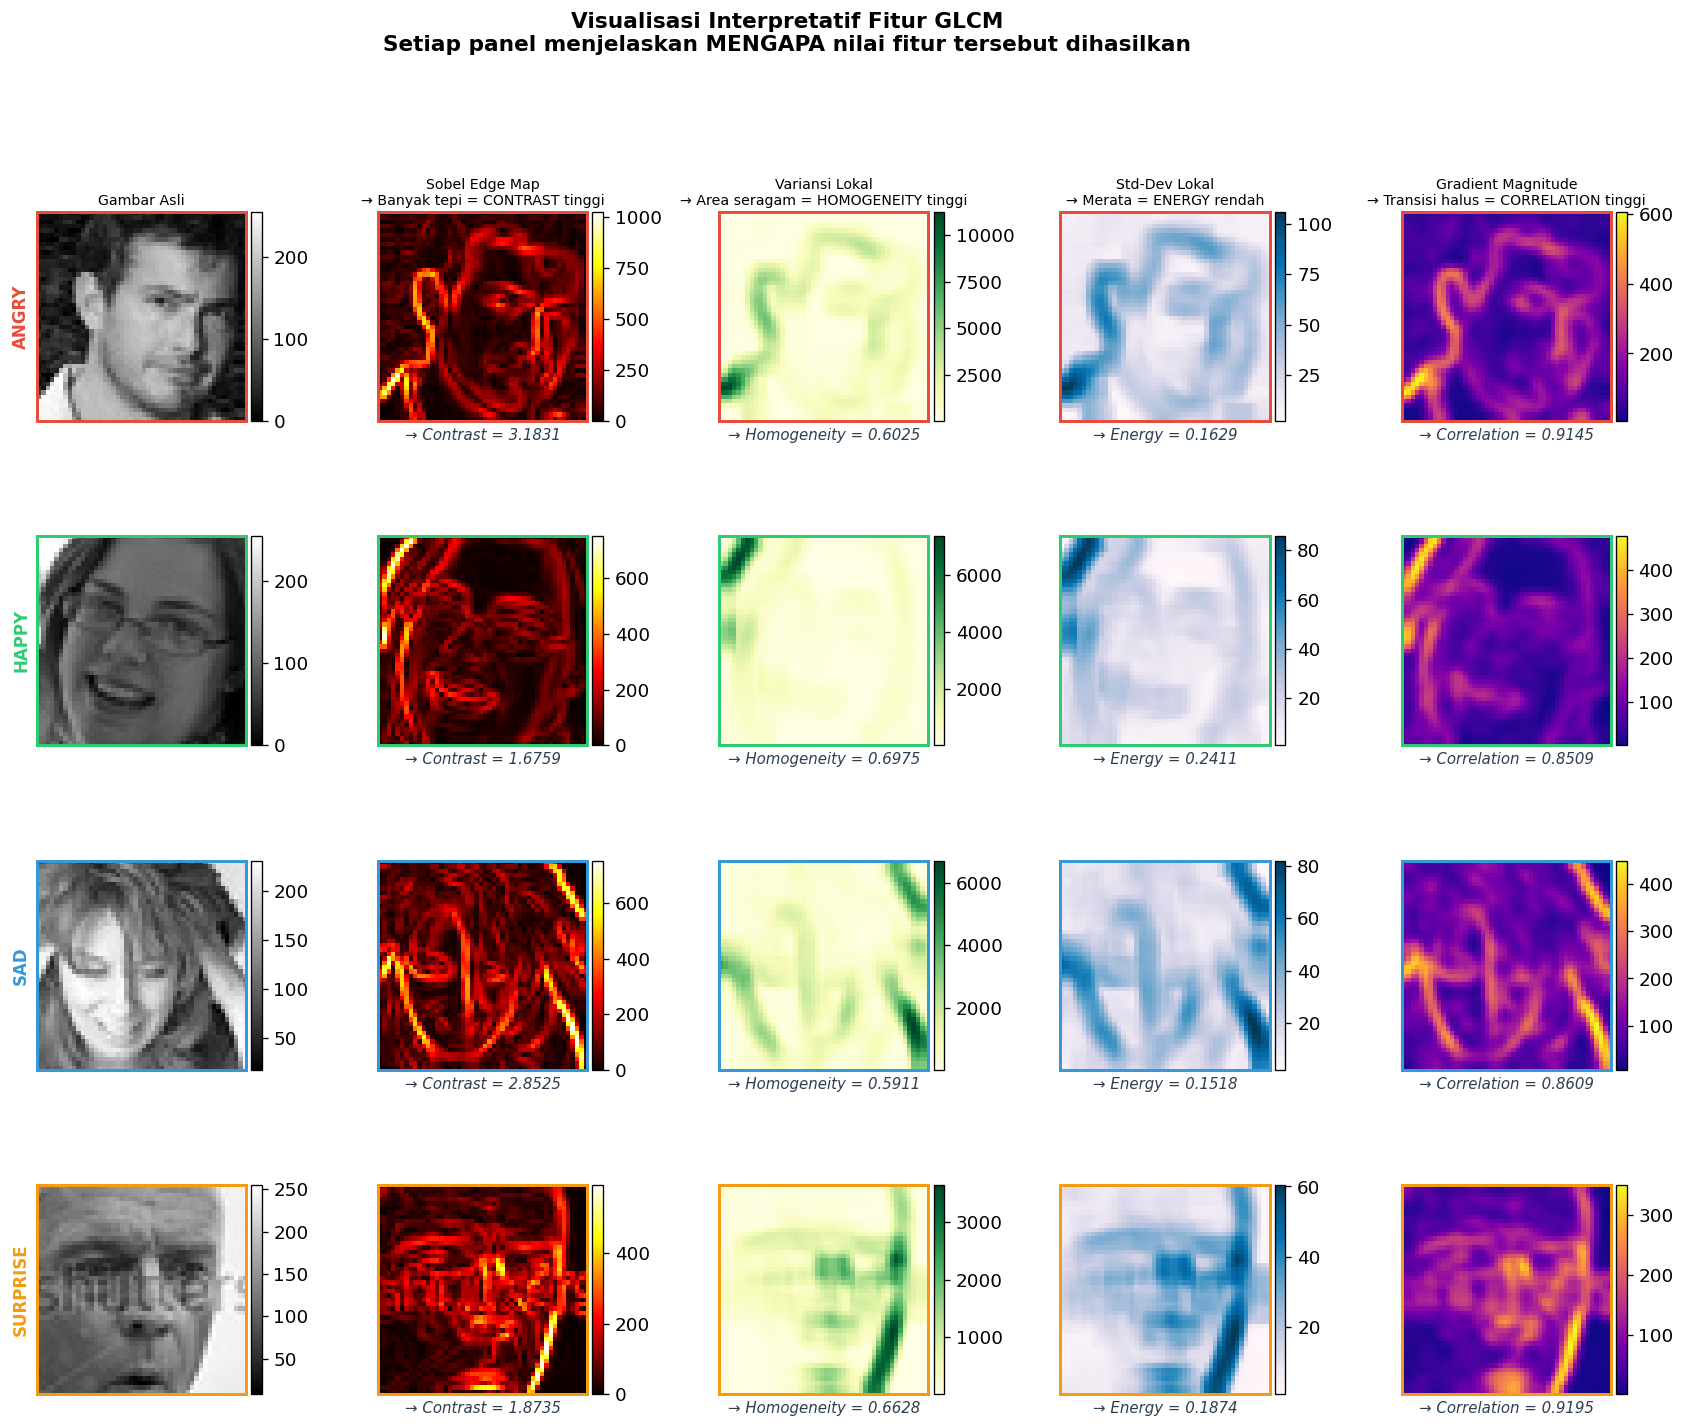

💾 Gambar disimpan: outputs\figures\04_interpretasi_fitur_glcm.png


In [8]:
# ================================================================
#  CELL 2.3 — Visualisasi Interpretatif: Mengapa Nilai Fitur Segitu?
# ================================================================

def compute_local_variance(img, kernel_size=7):
    """Hitung variansi lokal menggunakan sliding window."""
    img_f   = img.astype(np.float32)
    mean_sq = cv2.blur(img_f**2, (kernel_size, kernel_size))
    sq_mean = cv2.blur(img_f,    (kernel_size, kernel_size))**2
    return np.clip(mean_sq - sq_mean, 0, None)


def compute_local_entropy(img, kernel_size=7):
    """Aproksimasi entropy lokal via standar deviasi lokal."""
    img_f  = img.astype(np.float32)
    var    = compute_local_variance(img, kernel_size)
    return np.sqrt(var + 1e-6)   # std deviation ≈ indikator entropy


# Ambil 1 gambar per kelas
samples_for_interp = get_sample_per_class(train_raw, train_norm, train_labels)

# --- Layout: 4 kelas × 5 panel ---
# Panel: [Gambar Asli | Sobel (Contrast) | Var Lokal (Homogeneity) | Entropy (Energy) | Gradient (Correlation)]
panel_titles = [
    'Gambar Asli',
    'Sobel Edge Map\n→ Banyak tepi = CONTRAST tinggi',
    'Variansi Lokal\n→ Area seragam = HOMOGENEITY tinggi',
    'Std-Dev Lokal\n→ Merata = ENERGY rendah',
    'Gradient Magnitude\n→ Transisi halus = CORRELATION tinggi',
]
n_panels = len(panel_titles)

fig, axes = plt.subplots(
    len(CLASSES), n_panels,
    figsize=(n_panels * 3.5, len(CLASSES) * 3.2),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.3}
)
fig.suptitle(
    'Visualisasi Interpretatif Fitur GLCM\n'
    'Setiap panel menjelaskan MENGAPA nilai fitur tersebut dihasilkan',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_raw  = samples_for_interp[cls]['raw']    # uint8
    img_norm = samples_for_interp[cls]['norm']   # float32

    # --- Hitung semua peta turunan ---
    # 1. Sobel edge detection (gradient)
    sobel_x   = cv2.Sobel(img_raw, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y   = cv2.Sobel(img_raw, cv2.CV_64F, 0, 1, ksize=3)
    edge_map  = np.sqrt(sobel_x**2 + sobel_y**2)  # Magnitude edge

    # 2. Variansi lokal (proxy untuk Homogeneity)
    local_var = compute_local_variance(img_raw, kernel_size=7)

    # 3. Std-dev lokal (proxy untuk Energy; entropy tinggi → energy rendah)
    local_std = np.sqrt(local_var + 1e-6)

    # 4. Gradient magnitude halus (proxy untuk Correlation)
    grad_smooth = cv2.GaussianBlur(edge_map, (5,5), 0)

    # --- Ekstrak nilai fitur GLCM untuk anotasi ---
    feat, glcm_img = extract_glcm_features(img_norm, levels=16, aggregation='mean')
    feat_dict = dict(zip(GLCM_PROPS, feat))

    panels = [
        (img_raw,    'gray',  None),
        (edge_map,   'hot',   f"→ Contrast = {feat_dict['contrast']:.4f}"),
        (local_var,  'YlGn',  f"→ Homogeneity = {feat_dict['homogeneity']:.4f}"),
        (local_std,  'PuBu',  f"→ Energy = {feat_dict['energy']:.4f}"),
        (grad_smooth,'plasma',f"→ Correlation = {feat_dict['correlation']:.4f}"),
    ]

    for col, (panel_img, cmap, feat_val) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(panel_img, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

        if col == 0:
            ax.set_ylabel(f'{cls.upper()}', fontsize=10, color=color, fontweight='bold')
        if row == 0:
            ax.set_title(panel_titles[col], fontsize=8.5, pad=4)
        if feat_val:
            ax.set_xlabel(feat_val, fontsize=9, color='#2c3e50', style='italic')

        ax.set_xticks([]); ax.set_yticks([])

        # Border berwarna per kelas
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(1.8)

plt.savefig(str(OUT_FIGS / '04_interpretasi_fitur_glcm.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '04_interpretasi_fitur_glcm.png')

## 2.4 Perbandingan Nilai Fitur Antar Kelas

Bar chart perbandingan nilai rata-rata semua gambar per kelas untuk setiap fitur GLCM.

⏳ Menghitung rata-rata fitur GLCM per kelas (mungkin perlu beberapa menit)...
   [angry] selesai: 3100 gambar
   [happy] selesai: 3100 gambar
   [sad] selesai: 3100 gambar
   [surprise] selesai: 3100 gambar


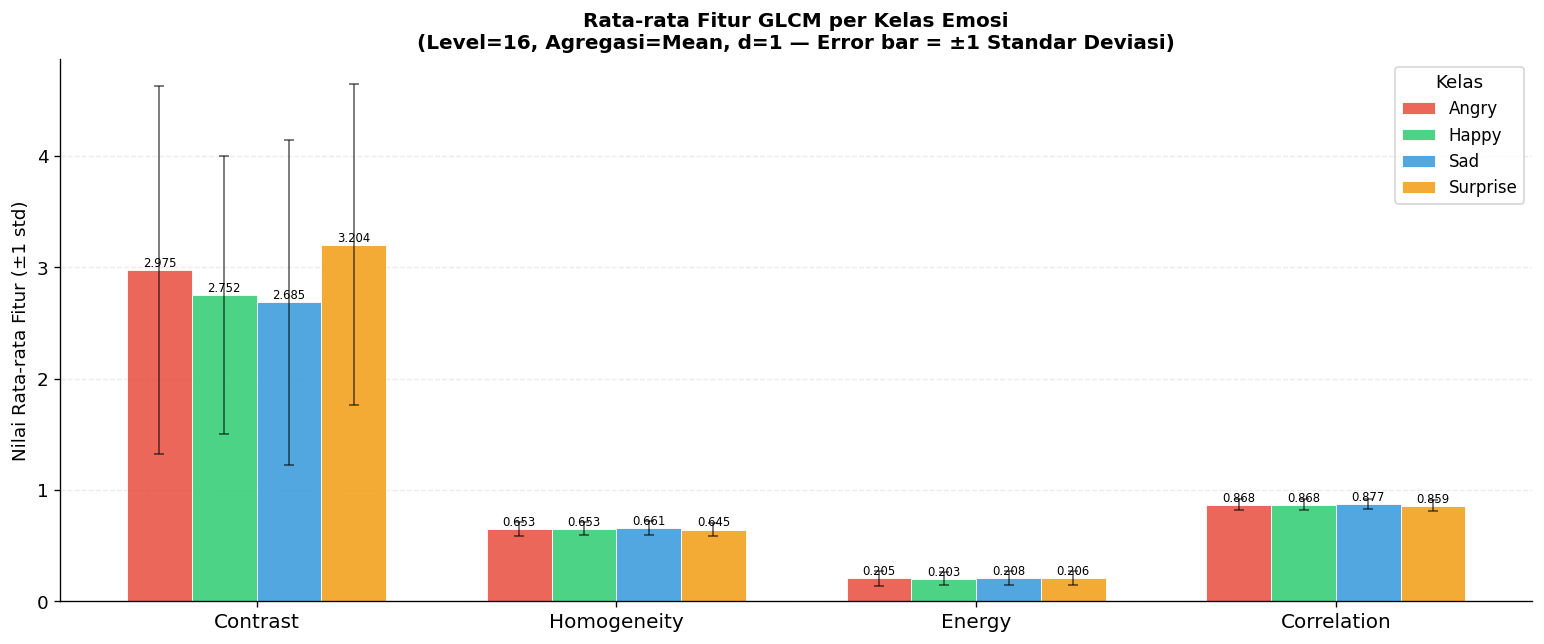

💾 Gambar disimpan: outputs\figures\05_glcm_feature_bar.png


In [10]:
# ================================================================
#  CELL 2.4 — Bar Chart Nilai Fitur GLCM Antar Kelas (Rata-rata)
# ================================================================

# Hitung rata-rata fitur dari SEMUA gambar per kelas
class_feat_means = {cls: [] for cls in CLASSES}
class_feat_stds  = {cls: [] for cls in CLASSES}

print("⏳ Menghitung rata-rata fitur GLCM per kelas (mungkin perlu beberapa menit)...")
for cls in CLASSES:
    feats_cls = [
        extract_glcm_features(img, levels=16, aggregation='mean')[0]
        for img, lbl in zip(train_norm, train_labels) if lbl == cls
    ]
    feats_arr = np.array(feats_cls)  # shape: (n_sampel, 4)
    class_feat_means[cls] = feats_arr.mean(axis=0)
    class_feat_stds[cls]  = feats_arr.std(axis=0)
    print(f"   [{cls}] selesai: {len(feats_cls)} gambar")

# --- Plot ---
x   = np.arange(len(GLCM_PROPS))
w   = 0.18
fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    offset = (i - (len(CLASSES)-1)/2) * w
    bars = ax.bar(
        x + offset,
        class_feat_means[cls],
        width=w,
        label=cls.capitalize(),
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.6
    )
    # Error bar (±1 std)
    ax.errorbar(
        x + offset,
        class_feat_means[cls],
        yerr=class_feat_stds[cls],
        fmt='none',
        ecolor='black',
        elinewidth=1,
        capsize=3,
        alpha=0.6
    )
    # Anotasi nilai
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in GLCM_PROPS], fontsize=12)
ax.set_ylabel('Nilai Rata-rata Fitur (±1 std)', fontsize=11)
ax.set_title(
    'Rata-rata Fitur GLCM per Kelas Emosi\n'
    '(Level=16, Agregasi=Mean, d=1 — Error bar = ±1 Standar Deviasi)',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Kelas', fontsize=10)
ax.grid(axis='y', alpha=0.25, ls='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '05_glcm_feature_bar.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '05_glcm_feature_bar.png')

---
# BAGIAN 3 — Pemodelan & Visualisasi Logistic Regression

## 3.1 Ekstraksi Fitur Massal & Simpan ke Disk

Sebelum training, kita ekstrak fitur untuk semua 6 skenario dan **simpan ke disk**.  
Jika sudah pernah dijalankan, cell ini akan langsung memuat dari cache.

### Mengapa StandardScaler Wajib untuk Logistic Regression?

Logistic Regression mengoptimasi fungsi loss menggunakan gradient descent.  
Jika fitur memiliki skala yang berbeda (Contrast ≈ 10⁻² vs Correlation ≈ 10⁰),  
gradiennya akan sangat tidak seimbang → konvergensi lambat atau tidak stabil.

```python
# StandardScaler: z = (x - μ) / σ
# Setelah scaling: mean=0, std=1 untuk setiap fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)  # Belajar μ,σ dari TRAIN saja
X_test  = scaler.transform(X_test_raw)       # Terapkan μ,σ yang sama ke TEST
# !! Jangan fit pada test set — ini akan menyebabkan data leakage !!
```

In [11]:
# ================================================================
#  CELL 3.1 — Ekstraksi Fitur Massal + Simpan ke Disk
# ================================================================

le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)

print("🔢 Pemetaan Label:", dict(zip(le.classes_, le.transform(le.classes_))))

scenarios = {}

for level in LEVELS_TO_TEST:
    for agg in ['mean', 'concat']:
        key        = f"{level}-{agg}"
        feat_path  = OUT_FEAT / f'features_{key}.pkl'

        # --- Muat dari cache jika tersedia ---
        if feat_path.exists():
            print(f"  📦 Cache ditemukan: {key}", end=" ")
            with open(feat_path, 'rb') as f:
                cached = pickle.load(f)
            scenarios[key] = cached
            print(f"→ {cached['X_train'].shape}")
            continue

        print(f"  ⚙️  Ekstraksi {key}...", end=' ')

        X_tr_raw = np.array([
            extract_glcm_features(img, level, aggregation=agg)[0]
            for img in train_norm
        ], dtype=np.float32)

        X_te_raw = np.array([
            extract_glcm_features(img, level, aggregation=agg)[0]
            for img in test_norm
        ], dtype=np.float32)

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_tr_raw)
        X_test  = scaler.transform(X_te_raw)

        data = {'X_train': X_train, 'X_test': X_test,
                'scaler': scaler, 'n_feat': X_train.shape[1]}
        scenarios[key] = data

        with open(feat_path, 'wb') as f:
            pickle.dump(data, f)

        print(f"✅ {X_train.shape} — disimpan ke {feat_path.name}")

print("\n🎯 Semua fitur siap!")

🔢 Pemetaan Label: {np.str_('angry'): np.int64(0), np.str_('happy'): np.int64(1), np.str_('sad'): np.int64(2), np.str_('surprise'): np.int64(3)}
  ⚙️  Ekstraksi 8-mean... ✅ (12400, 4) — disimpan ke features_8-mean.pkl
  ⚙️  Ekstraksi 8-concat... ✅ (12400, 16) — disimpan ke features_8-concat.pkl
  ⚙️  Ekstraksi 16-mean... ✅ (12400, 4) — disimpan ke features_16-mean.pkl
  ⚙️  Ekstraksi 16-concat... ✅ (12400, 16) — disimpan ke features_16-concat.pkl
  ⚙️  Ekstraksi 32-mean... ✅ (12400, 4) — disimpan ke features_32-mean.pkl
  ⚙️  Ekstraksi 32-concat... ✅ (12400, 16) — disimpan ke features_32-concat.pkl

🎯 Semua fitur siap!


## 3.2 Training Model Logistic Regression

### Bedah Parameter:

```python
LogisticRegression(
    max_iter     = 1000,  # Iterasi maksimum solver
    solver       = 'lbfgs',  # Algoritma optimasi:
                          #   'lbfgs' = Limited-memory Broyden–Fletcher–Goldfarb–Shanno
                          #   Cocok untuk dataset kecil-menengah, mendukung multi-class
    C            = 1.0,   # 1/lambda (invers kekuatan regularisasi L2)
                          #   C kecil → bobot model kecil, bias tinggi (underfitting)
                          #   C besar → bobot besar, variansi tinggi (overfitting)
    random_state = 42
)
```

### Bagaimana Logistic Regression Menangani Multi-Kelas?
Secara default (solver='lbfgs'), scikit-learn menggunakan strategi **One-vs-Rest (OvR)**:  
- Buat 4 classifier biner: `angry vs [rest]`, `happy vs [rest]`, dst.
- Setiap classifier belajar memisahkan 1 kelas dari semua kelas lainnya
- Prediksi akhir = kelas dengan probabilitas tertinggi

In [12]:
# ================================================================
#  CELL 3.2 — Training & Simpan Semua Model
# ================================================================

results = {}

print(f"{'Skenario':<20} {'Dim':>5} {'Acc Train':>11} {'Acc Test':>10}")
print("-" * 50)

for key, data in scenarios.items():
    model_path = OUT_MODELS / f'model_{key}.pkl'

    if model_path.exists():
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
    else:
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        model.fit(data['X_train'], y_train)
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)

    y_pred_tr = model.predict(data['X_train'])
    y_pred_te = model.predict(data['X_test'])
    acc_tr    = accuracy_score(y_train, y_pred_tr)
    acc_te    = accuracy_score(y_test,  y_pred_te)

    results[key] = {
        'model': model, 'y_pred_test': y_pred_te,
        'acc_train': acc_tr, 'acc_test': acc_te
    }
    print(f"{key:<20} {data['n_feat']:>5} {acc_tr:>11.4f} {acc_te:>10.4f}")

best_key = max(results, key=lambda k: results[k]['acc_test'])
best_acc = results[best_key]['acc_test']
print("-" * 50)
print(f"\n🏆 Terbaik: '{best_key}' — Akurasi Test = {best_acc:.4f} ({best_acc:.2%})")
print(f"💾 Semua model disimpan di {OUT_MODELS}/")

Skenario               Dim   Acc Train   Acc Test
--------------------------------------------------
8-mean                   4      0.3219     0.3152
8-concat                16      0.3687     0.3823
16-mean                  4      0.3143     0.3100
16-concat               16      0.3652     0.3765
32-mean                  4      0.3142     0.3116
32-concat               16      0.3603     0.3765
--------------------------------------------------

🏆 Terbaik: '8-concat' — Akurasi Test = 0.3823 (38.23%)
💾 Semua model disimpan di outputs\models/


## 3.3 Visualisasi Internal Logistic Regression

Ini adalah bagian yang sering dilewati padahal sangat penting untuk benar-benar **memahami apa yang dilakukan model**.

### Visualisasi yang Akan Dibuat:

**1. Decision Boundary di Ruang 2D (PCA)**  
Kita proyeksikan fitur ke 2D dengan PCA, lalu plot garis batas keputusan model.  
Ini menunjukkan: Logistic Regression hanya bisa membuat batas **linear** (garis lurus).

**2. Heatmap Bobot Model (Coefficient Matrix)**  
Model mempelajari satu vektor bobot `w` per kelas.  
Fitur dengan bobot positif besar → mendorong prediksi ke kelas itu.  
Fitur dengan bobot negatif besar → menghambat prediksi ke kelas itu.

**3. Probabilitas Prediksi (Confidence)**  
Logistic Regression menghasilkan probabilitas per kelas, bukan hanya label.  
Gambar yang salah diprediksi sering memiliki probabilitas yang rendah atau merata.

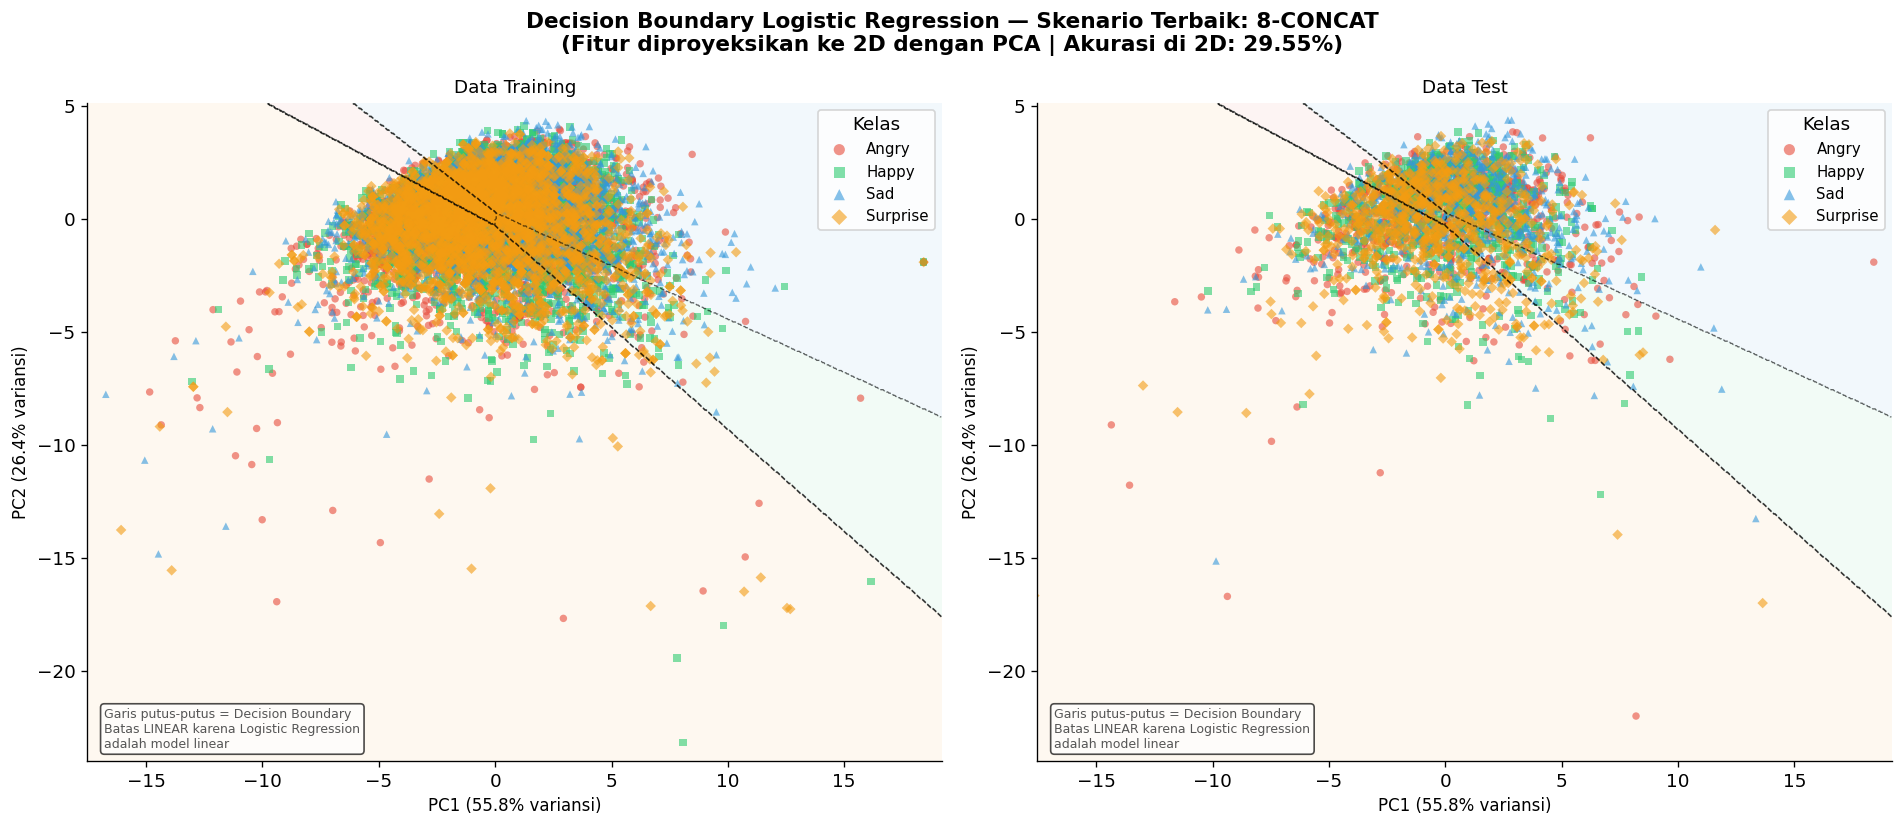

💾 Gambar disimpan: outputs\figures\06_decision_boundary.png


In [13]:
# ================================================================
#  CELL 3.3a — Decision Boundary Logistic Regression di Ruang PCA
# ================================================================

best_model  = results[best_key]['model']
X_tr_best   = scenarios[best_key]['X_train']
X_te_best   = scenarios[best_key]['X_test']

# Reduksi ke 2D dengan PCA untuk visualisasi
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_tr_2d = pca_2d.fit_transform(X_tr_best)
X_te_2d = pca_2d.transform(X_te_best)

# Latih Logistic Regression baru pada fitur 2D (untuk visualisasi batas)
lr_2d = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_2d.fit(X_tr_2d, y_train)
acc_2d = accuracy_score(y_test, lr_2d.predict(X_te_2d))

# --- Buat meshgrid untuk menggambar decision region ---
margin  = 0.8
x_min, x_max = X_tr_2d[:, 0].min() - margin, X_tr_2d[:, 0].max() + margin
y_min, y_max = X_tr_2d[:, 1].min() - margin, X_tr_2d[:, 1].max() + margin
h = 0.05  # Resolusi grid

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)
# Prediksi kelas untuk setiap titik di meshgrid
# np.c_: gabungkan dua array kolom menjadi matrix
Z = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'Decision Boundary Logistic Regression — Skenario Terbaik: {best_key.upper()}\n'
    f'(Fitur diproyeksikan ke 2D dengan PCA | Akurasi di 2D: {acc_2d:.2%})',
    fontsize=13, fontweight='bold'
)

# Buat colormap kustom yang lembut untuk region
region_colors = ['#fadbd8', '#d5f5e3', '#d6eaf8', '#fdebd0']  # Versi pastel COLORS
cmap_region   = LinearSegmentedColormap.from_list('regions', region_colors, N=4)

for ax, (X_2d, y_true, title) in zip(axes, [
    (X_tr_2d, y_train, 'Data Training'),
    (X_te_2d, y_test,  'Data Test')
]):
    # Gambar region keputusan (warna latar belakang)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_region, levels=[-0.5, 0.5, 1.5, 2.5, 3.5])

    # Gambar garis batas keputusan (kontur tanpa fill)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8, linestyles='--',
               levels=[-0.5, 0.5, 1.5, 2.5, 3.5], alpha=0.6)

    # Plot titik data per kelas
    markers = ['o', 's', '^', 'D']
    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, COLORS, markers)):
        mask = y_true == cls_idx
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=color, marker=marker, s=20, alpha=0.6,
            label=cls.capitalize(), edgecolors='none'
        )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variansi)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variansi)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(title='Kelas', fontsize=9, markerscale=1.5)

    # Anotasi penjelasan
    ax.text(0.02, 0.02,
            'Garis putus-putus = Decision Boundary\n'
            'Batas LINEAR karena Logistic Regression\n'
            'adalah model linear',
            transform=ax.transAxes, fontsize=7.5, color='#555',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '06_decision_boundary.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '06_decision_boundary.png')

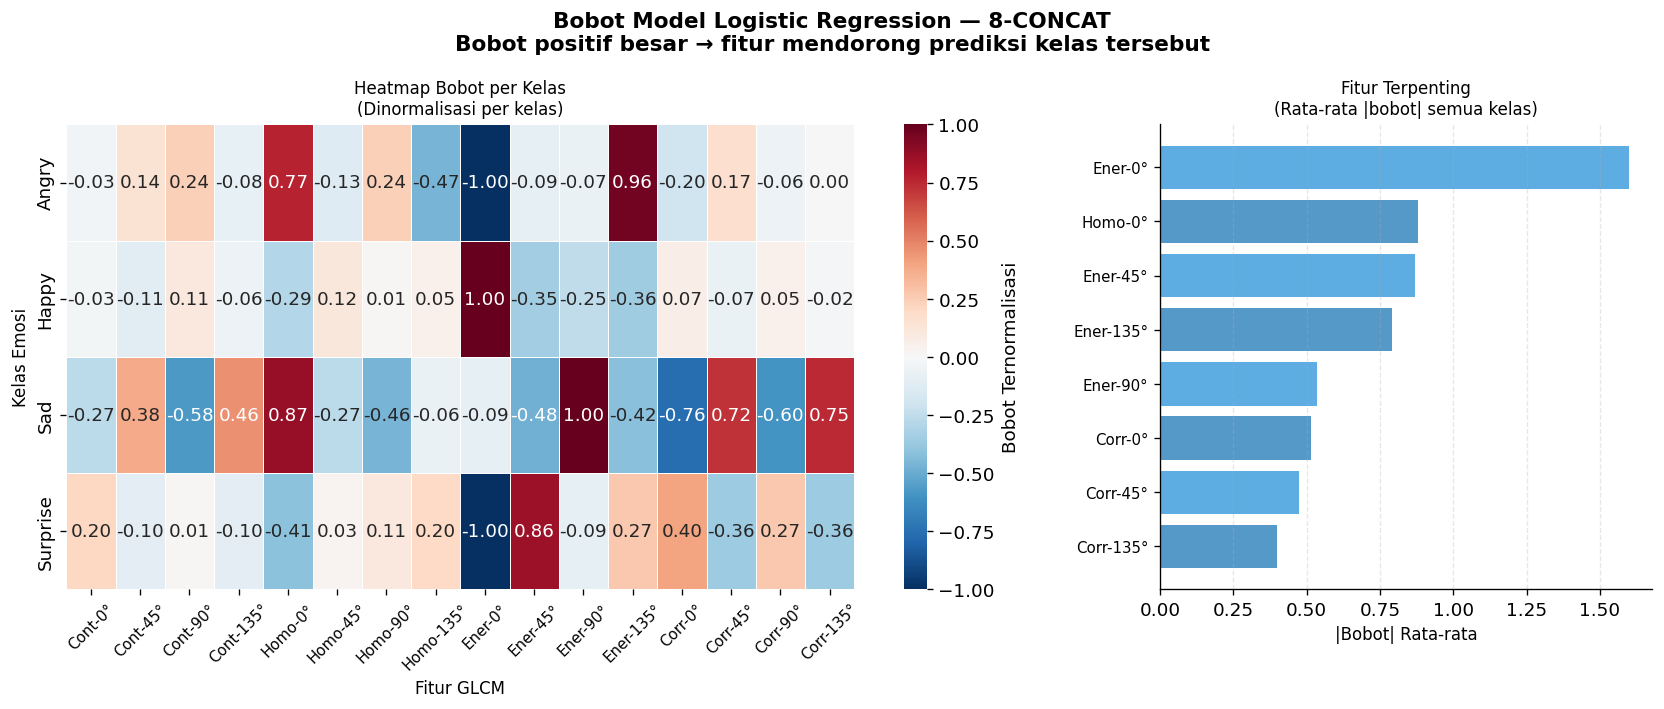

💾 Gambar disimpan: outputs\figures\07_model_coefficients.png


In [14]:
# ================================================================
#  CELL 3.3b — Heatmap Bobot Model (Coefficient Matrix)
# ================================================================

# best_model.coef_ → shape (n_classes, n_features)
# Setiap baris = vektor bobot untuk satu kelas
coef_matrix = best_model.coef_    # (4, n_feat)
n_feat      = coef_matrix.shape[1]
level, agg  = best_key.split('-')

# Nama fitur berdasarkan skenario
if agg == 'mean':
    feat_names = [p.capitalize() for p in GLCM_PROPS]   # 4 nama
else:
    # Concat: setiap fitur × 4 sudut = 16 nama
    feat_names = [f'{p[:4].capitalize()}-{a}' for p in GLCM_PROPS for a in ANGLE_LABELS]

class_names_cap = [c.capitalize() for c in le.classes_]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle(
    f'Bobot Model Logistic Regression — {best_key.upper()}\n'
    'Bobot positif besar → fitur mendorong prediksi kelas tersebut',
    fontsize=13, fontweight='bold'
)

# --- Panel kiri: Heatmap semua bobot ---
ax_coef = axes[0]
# Normalisasi bobot per baris agar perbandingannya lebih jelas
coef_norm = coef_matrix / np.abs(coef_matrix).max(axis=1, keepdims=True)

sns.heatmap(
    coef_norm,
    ax=ax_coef,
    annot=True, fmt='.2f',
    cmap='RdBu_r',       # Merah = positif kuat, Biru = negatif kuat
    center=0,            # Tengah colorbar di nilai 0
    xticklabels=feat_names,
    yticklabels=class_names_cap,
    linewidths=0.3,
    cbar_kws={'label': 'Bobot Ternormalisasi'}
)
ax_coef.set_title('Heatmap Bobot per Kelas\n(Dinormalisasi per kelas)', fontsize=10)
ax_coef.set_xlabel('Fitur GLCM', fontsize=10)
ax_coef.set_ylabel('Kelas Emosi', fontsize=10)
ax_coef.tick_params(axis='x', rotation=45, labelsize=9)

# --- Panel kanan: Bar chart bobot absolut per kelas (top features) ---
ax_bar = axes[1]
abs_mean_coef = np.abs(coef_matrix).mean(axis=0)  # Rata-rata bobot absolut per fitur

sorted_idx = np.argsort(abs_mean_coef)[::-1]  # Urutan dari terbesar
top_n      = min(8, len(abs_mean_coef))

ax_bar.barh(
    range(top_n),
    abs_mean_coef[sorted_idx[:top_n]],
    color=['#3498db' if i % 2 == 0 else '#2980b9' for i in range(top_n)],
    alpha=0.8
)
ax_bar.set_yticks(range(top_n))
ax_bar.set_yticklabels([feat_names[i] for i in sorted_idx[:top_n]], fontsize=9)
ax_bar.set_xlabel('|Bobot| Rata-rata', fontsize=10)
ax_bar.set_title('Fitur Terpenting\n(Rata-rata |bobot| semua kelas)', fontsize=10)
ax_bar.invert_yaxis()   # Fitur paling penting di atas
ax_bar.grid(axis='x', alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '07_model_coefficients.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '07_model_coefficients.png')

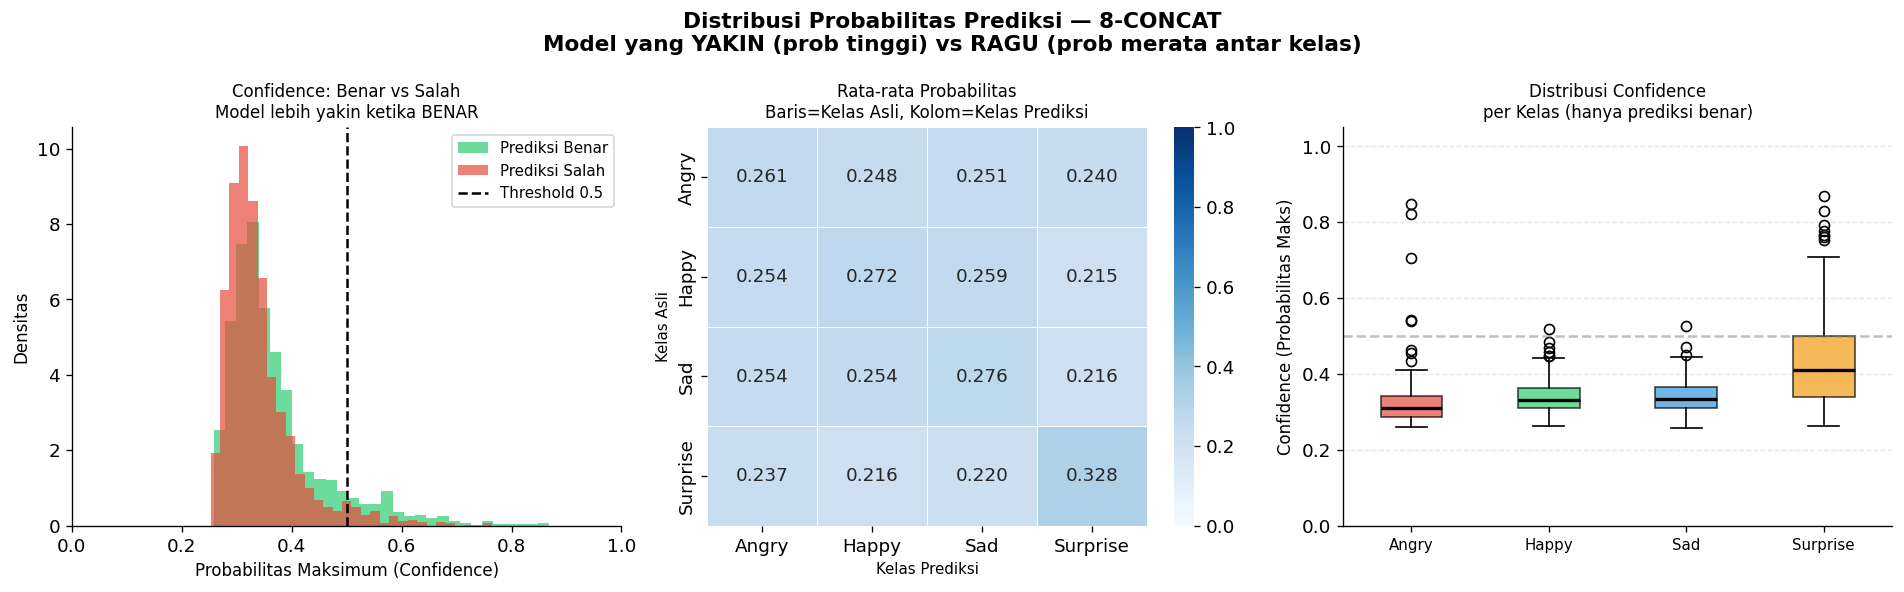

💾 Gambar disimpan: outputs\figures\08_prediction_probability.png


In [15]:
# ================================================================
#  CELL 3.3c — Distribusi Probabilitas Prediksi
# ================================================================

# best_model.predict_proba → probabilitas per kelas untuk setiap sampel
# shape: (n_samples, n_classes)
proba_all = best_model.predict_proba(X_te_best)

# Pisahkan: prediksi BENAR vs SALAH
is_correct  = (results[best_key]['y_pred_test'] == y_test)
max_proba   = proba_all.max(axis=1)   # Probabilitas kelas pemenang

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Distribusi Probabilitas Prediksi — {best_key.upper()}\n'
    'Model yang YAKIN (prob tinggi) vs RAGU (prob merata antar kelas)',
    fontsize=13, fontweight='bold'
)

# --- Panel 1: Distribusi probabilitas maksimum (benar vs salah) ---
ax = axes[0]
ax.hist(max_proba[is_correct],  bins=30, color='#2ecc71', alpha=0.7,
        label='Prediksi Benar', density=True)
ax.hist(max_proba[~is_correct], bins=30, color='#e74c3c', alpha=0.7,
        label='Prediksi Salah', density=True)
ax.axvline(0.5, color='black', lw=1.5, ls='--', label='Threshold 0.5')
ax.set_xlabel('Probabilitas Maksimum (Confidence)', fontsize=10)
ax.set_ylabel('Densitas', fontsize=10)
ax.set_title('Confidence: Benar vs Salah\n'
             'Model lebih yakin ketika BENAR', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

# --- Panel 2: Heatmap rata-rata probabilitas per kelas TRUE ---
ax = axes[1]
avg_proba_per_class = np.zeros((len(le.classes_), len(le.classes_)))
for true_idx in range(len(le.classes_)):
    mask = y_test == true_idx
    if mask.sum() > 0:
        avg_proba_per_class[true_idx] = proba_all[mask].mean(axis=0)

sns.heatmap(
    avg_proba_per_class,
    ax=ax,
    annot=True, fmt='.3f',
    cmap='Blues',
    xticklabels=class_names_cap,
    yticklabels=class_names_cap,
    vmin=0, vmax=1,
    linewidths=0.5
)
ax.set_title('Rata-rata Probabilitas\nBaris=Kelas Asli, Kolom=Kelas Prediksi', fontsize=10)
ax.set_xlabel('Kelas Prediksi', fontsize=9)
ax.set_ylabel('Kelas Asli', fontsize=9)

# --- Panel 3: Box plot confidence per kelas yang benar ---
ax = axes[2]
correct_conf_per_class = [
    max_proba[(y_test == cls_idx) & is_correct]
    for cls_idx in range(len(le.classes_))
]
bp = ax.boxplot(
    correct_conf_per_class,
    patch_artist=True,
    medianprops={'color': 'black', 'lw': 2}
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(class_names_cap, fontsize=9)
ax.set_ylabel('Confidence (Probabilitas Maks)', fontsize=10)
ax.set_title('Distribusi Confidence\nper Kelas (hanya prediksi benar)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '08_prediction_probability.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '08_prediction_probability.png')

---
# BAGIAN 4 — Evaluasi Lengkap

## 4.1 Classification Report

In [16]:
# ================================================================
#  CELL 4.1 — Classification Report
# ================================================================

y_pred_best = results[best_key]['y_pred_test']
class_names_cap = [c.capitalize() for c in le.classes_]

print(f"{'='*62}")
print(f"  📊 CLASSIFICATION REPORT — Skenario: {best_key.upper()}")
print(f"{'='*62}")
print(classification_report(y_test, y_pred_best, target_names=class_names_cap))

  📊 CLASSIFICATION REPORT — Skenario: 8-CONCAT
              precision    recall  f1-score   support

       Angry       0.36      0.20      0.25       775
       Happy       0.36      0.36      0.36       775
         Sad       0.36      0.40      0.38       775
    Surprise       0.43      0.57      0.49       775

    accuracy                           0.38      3100
   macro avg       0.38      0.38      0.37      3100
weighted avg       0.38      0.38      0.37      3100



## 4.2 Confusion Matrix

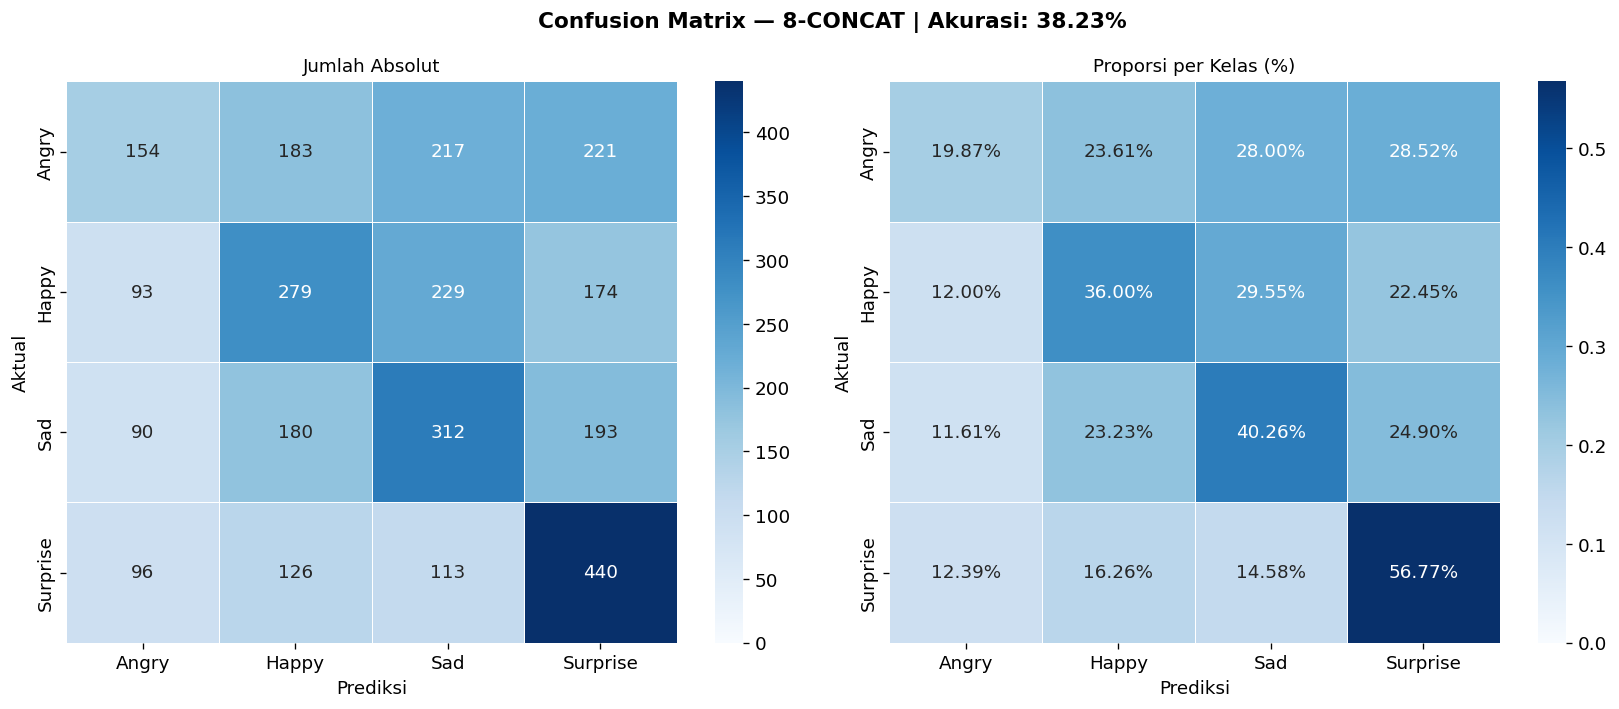

💾 Gambar disimpan: outputs\figures\09_confusion_matrix.png


In [17]:
# ================================================================
#  CELL 4.2 — Confusion Matrix (Absolut + Normalized)
# ================================================================

cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Confusion Matrix — {best_key.upper()} | Akurasi: {best_acc:.2%}',
             fontsize=13, fontweight='bold')

for ax, (data, fmt, title, cmap) in zip(axes, [
    (cm,      'd',    'Jumlah Absolut',          'Blues'),
    (cm_norm, '.2%',  'Proporsi per Kelas (%)',  'Blues')
]):
    sns.heatmap(data, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names_cap, yticklabels=class_names_cap,
                linewidths=0.5, linecolor='white', vmin=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '09_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '09_confusion_matrix.png')

## 4.3 Perbandingan Akurasi 6 Skenario

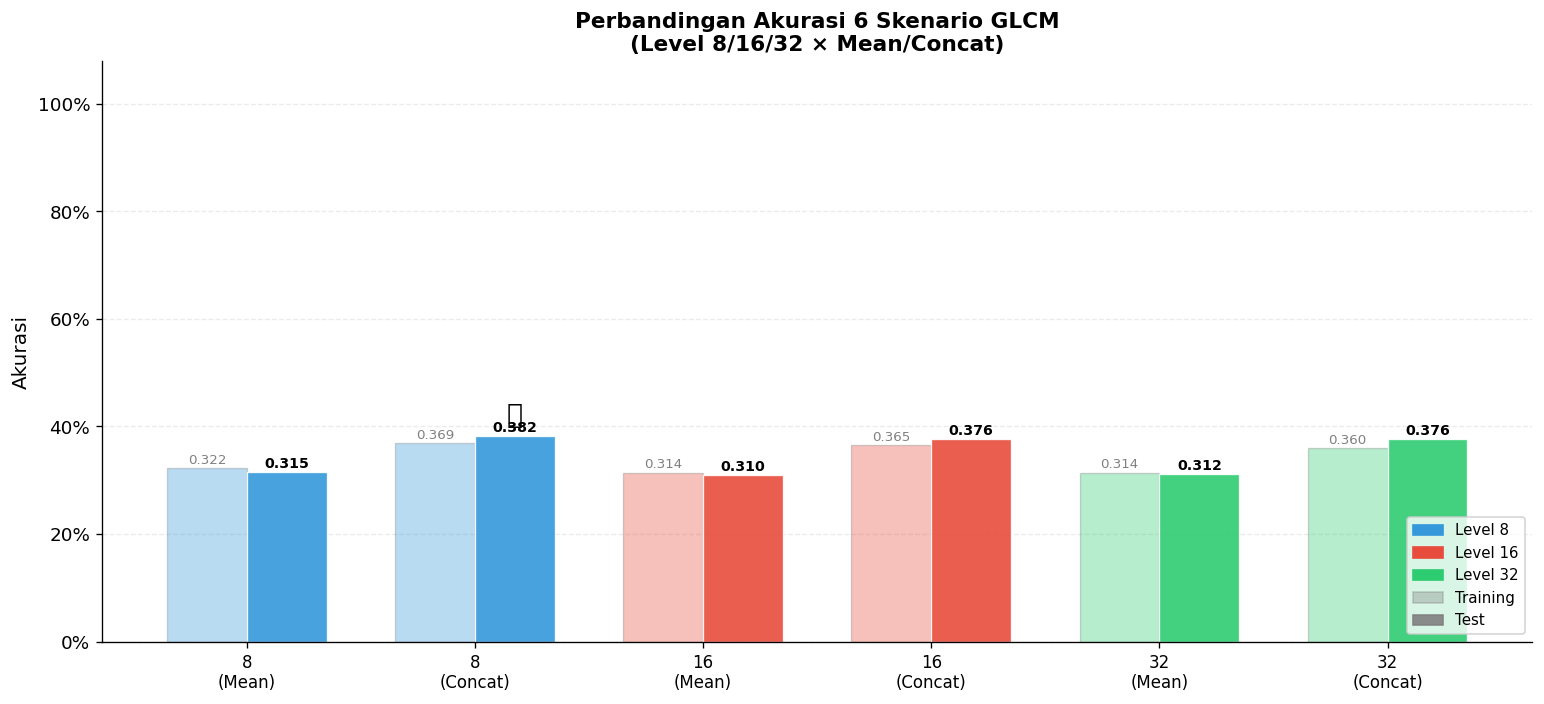

💾 Gambar disimpan: outputs\figures\10_accuracy_comparison.png


In [18]:
# ================================================================
#  CELL 4.3 — Bar Chart Perbandingan 6 Skenario
# ================================================================

keys      = list(results.keys())
acc_train = [results[k]['acc_train'] for k in keys]
acc_test  = [results[k]['acc_test']  for k in keys]
x         = np.arange(len(keys))
w         = 0.35

level_colors_map = {'8': '#3498db', '16': '#e74c3c', '32': '#2ecc71'}
bar_colors       = [level_colors_map[k.split('-')[0]] for k in keys]

fig, ax = plt.subplots(figsize=(13, 6))
bars_tr = ax.bar(x - w/2, acc_train, w, color=bar_colors, alpha=0.35,
                 edgecolor='gray', lw=0.8, label='Training')
bars_te = ax.bar(x + w/2, acc_test,  w, color=bar_colors, alpha=0.9,
                 edgecolor='white', lw=0.8, label='Test')

for bar, val in zip(bars_tr, acc_train):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='gray')
for bar, val in zip(bars_te, acc_test):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Tandai terbaik
best_idx = keys.index(best_key)
ax.annotate('⭐', xy=(x[best_idx] + w/2, acc_test[best_idx]),
            xytext=(x[best_idx] + w/2, acc_test[best_idx] + 0.025),
            fontsize=16, ha='center')

ax.set_xticks(x)
ax.set_xticklabels(
    [k.replace('-mean','\n(Mean)').replace('-concat','\n(Concat)') for k in keys],
    fontsize=10
)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Perbandingan Akurasi 6 Skenario GLCM\n(Level 8/16/32 × Mean/Concat)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#3498db', label='Level 8'),
    Patch(color='#e74c3c', label='Level 16'),
    Patch(color='#2ecc71', label='Level 32'),
    Patch(color='gray', alpha=0.35, label='Training'),
    Patch(color='gray', alpha=0.9,  label='Test'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '10_accuracy_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '10_accuracy_comparison.png')

## 4.4 PCA & t-SNE + Error Analysis

⏳ PCA... ✅  | ⏳ t-SNE... ✅


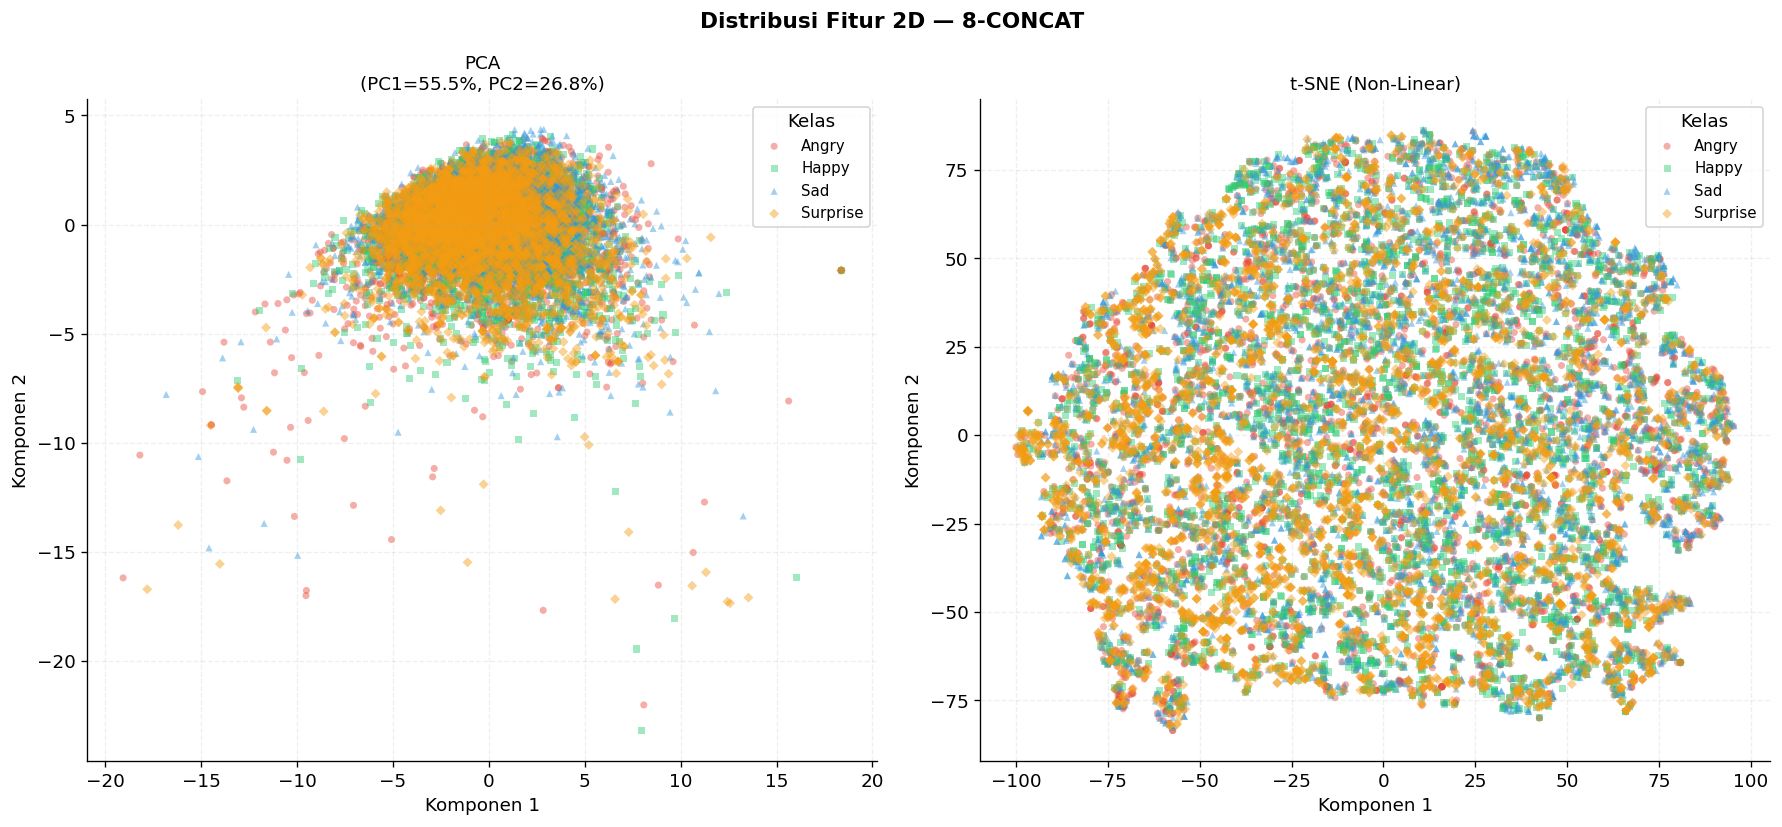

💾 Gambar disimpan: outputs\figures\11_pca_tsne.png


In [20]:
# ================================================================
#  CELL 4.4 — PCA & t-SNE Distribusi Fitur 2D
# ================================================================

X_all = np.vstack([X_tr_best, X_te_best])
y_all = np.concatenate([y_train, y_test])

print("⏳ PCA...", end=' ')
pca_full = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca_full.fit_transform(X_all)
print(f"✅  | ⏳ t-SNE...", end=' ')

tsne  = TSNE(n_components=2, perplexity=30,
             learning_rate='auto', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_all)
print("✅")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(f'Distribusi Fitur 2D — {best_key.upper()}', fontsize=13, fontweight='bold')
markers = ['o', 's', '^', 'D']

for ax, (X_2d, title) in zip(axes, [
    (X_pca,  f'PCA\n(PC1={pca_full.explained_variance_ratio_[0]:.1%}, PC2={pca_full.explained_variance_ratio_[1]:.1%})'),
    (X_tsne, 't-SNE (Non-Linear)')
]):
    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, COLORS, markers)):
        mask = y_all == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, marker=marker,
                   label=cls.capitalize(), alpha=0.45, s=18, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Komponen 1'); ax.set_ylabel('Komponen 2')
    ax.legend(title='Kelas', fontsize=9)
    ax.grid(True, alpha=0.2, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '11_pca_tsne.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '11_pca_tsne.png')

Total kesalahan: 1915 / 3100 (61.8%)


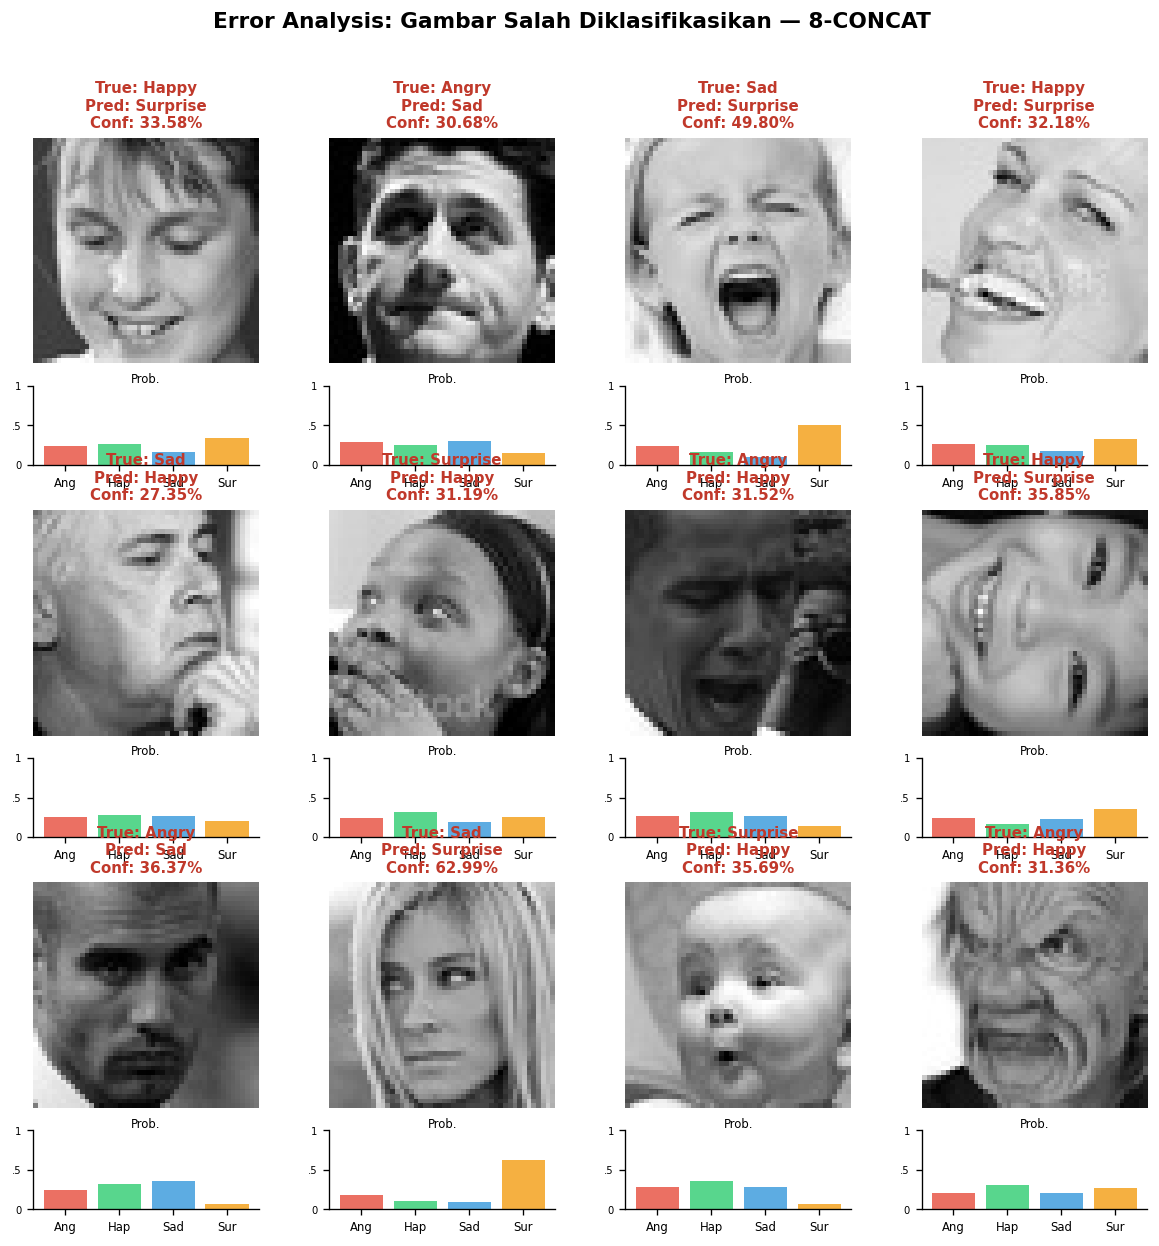

💾 Gambar disimpan: outputs\figures\12_error_analysis.png


In [21]:
# ================================================================
#  CELL 4.5 — Error Analysis: Grid Gambar Salah Klasifikasi
# ================================================================

wrong_idx = np.where(y_test != y_pred_best)[0]
print(f"Total kesalahan: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test):.1%})")

rng     = np.random.default_rng(RANDOM_STATE)
n_show  = min(12, len(wrong_idx))
sampled = rng.choice(wrong_idx, size=n_show, replace=False)

n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3, n_rows * 3.5),
                          gridspec_kw={'hspace': 0.65, 'wspace': 0.3})
fig.suptitle(f'Error Analysis: Gambar Salah Diklasifikasikan — {best_key.upper()}',
             fontsize=13, fontweight='bold')

for plot_idx, test_idx in enumerate(sampled):
    ax         = axes.flatten()[plot_idx]
    true_label = le.inverse_transform([y_test[test_idx]])[0].capitalize()
    pred_label = le.inverse_transform([y_pred_best[test_idx]])[0].capitalize()

    # Probabilitas semua kelas untuk gambar ini
    proba_img = proba_all[test_idx]
    conf      = proba_img.max()

    ax.imshow(test_raw[test_idx], cmap='gray')
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {conf:.2%}',
                 fontsize=9, color='#c0392b', fontweight='bold')

    # Mini bar probabilitas di bawah gambar
    ax_inset = ax.inset_axes([0, -0.45, 1, 0.35])
    bars = ax_inset.bar(range(4), proba_img, color=COLORS, alpha=0.8)
    ax_inset.set_xticks(range(4))
    ax_inset.set_xticklabels([c[:3].capitalize() for c in le.classes_], fontsize=7)
    ax_inset.set_ylim(0, 1)
    ax_inset.set_yticks([0, 0.5, 1])
    ax_inset.set_yticklabels(['0', '.5', '1'], fontsize=6)
    ax_inset.set_title('Prob.', fontsize=7, pad=1)
    ax_inset.spines['top'].set_visible(False)
    ax_inset.spines['right'].set_visible(False)

    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor('#e74c3c'); spine.set_linewidth(2)

for idx in range(n_show, n_rows * n_cols):
    axes.flatten()[idx].axis('off')

plt.savefig(str(OUT_FIGS / '12_error_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Gambar disimpan:", OUT_FIGS / '12_error_analysis.png')

---
# BAGIAN 5 — Ringkasan & Panduan Analisis Laporan

In [28]:
# ================================================================
#  CELL 6.1 — Rekap Semua File yang Tersimpan
# ================================================================

print("=" * 65)
print("  📁 REKAP FILE OUTPUT YANG TERSIMPAN")
print("=" * 65)

print("\n📊 HASIL EKSPERIMEN:")
print(f"  {'Skenario':<20} {'Dim':>5} {'Acc Train':>11} {'Acc Test':>10}")
print("  " + "-" * 48)
for key in results:
    level, agg = key.split('-')
    n = scenarios[key]['n_feat']
    at, ae = results[key]['acc_train'], results[key]['acc_test']
    mark = ' ⭐' if key == best_key else ''
    print(f"  {key:<20} {n:>5} {at:>11.4f} {ae:>10.4f}{mark}")
print("  " + "-" * 48)
print(f"  TERBAIK: {best_key.upper()} → Akurasi {best_acc:.4f} ({best_acc:.2%})")

print("\n🖼️  VISUALISASI (outputs/figures/):")
fig_files = sorted(OUT_FIGS.glob('*.png'))
for f in fig_files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>6.1f} KB")

print("\n🗃️  DATA TERSIMPAN:")
for folder, label in [(OUT_PREPROC, 'Preprocessed'), (OUT_FEAT, 'Features'), (OUT_MODELS, 'Models')]:
    files = list(folder.glob('*'))
    total_mb = sum(f.stat().st_size for f in files) / 1024 / 1024
    print(f"  {label} ({folder}): {len(files)} file, total {total_mb:.1f} MB")

print("""
=================================================================
📝 PANDUAN ANALISIS LAPORAN
=================================================================

1. EVALUASI UTAMA → Classification Report (Cell 4.1)
   Baca kolom F1-score per kelas. Kelas dengan F1 terendah
   adalah yang paling sulit diklasifikasikan.

2. ANALISIS 1 & 2 → Confusion Matrix (09_confusion_matrix.png)
   Diagonal = prediksi benar. Off-diagonal = jenis kesalahan.
   Kelas dengan recall terendah di normalized CM = paling sulit.

3. ANALISIS 3 → 10_accuracy_comparison.png
   Bandingkan level 8/16/32 dan Mean/Concat.
   Apakah level lebih tinggi selalu lebih baik?
   Apakah Concat (16 dim) lebih baik dari Mean (4 dim)?

4. ANALISIS 4 → 11_pca_tsne.png + 06_decision_boundary.png
   Jika kelas overlap besar di PCA → tidak linear separable.
   t-SNE memperlihatkan struktur non-linear yang tersembunyi.
   Decision boundary yang tidak sempurna → keterbatasan model linear.

5. ANALISIS 5 → 12_error_analysis.png
   Setiap gambar salah dilengkapi bar probabilitas.
   Confidence rendah = model ragu → ekspresi ambigu.
   Identifikasi pola: pencahayaan, pose, ekspresi halus.

6. FITUR GLCM → 04_interpretasi_fitur_glcm.png
   Gunakan untuk menjelaskan MENGAPA nilai contrast/homogeneity
   suatu gambar segitu. Sobel map = bukti visual untuk contrast.
=================================================================
""")

  📁 REKAP FILE OUTPUT YANG TERSIMPAN

📊 HASIL EKSPERIMEN:
  Skenario               Dim   Acc Train   Acc Test
  ------------------------------------------------
  8-mean                   4      0.3219     0.3152
  8-concat                16      0.3687     0.3823 ⭐
  16-mean                  4      0.3143     0.3100
  16-concat               16      0.3652     0.3765
  32-mean                  4      0.3142     0.3116
  32-concat               16      0.3603     0.3765
  ------------------------------------------------
  TERBAIK: 8-CONCAT → Akurasi 0.3823 (38.23%)

🖼️  VISUALISASI (outputs/figures/):
  01_before_after_histogram.png                  359.3 KB
  02_histogram_overlay.png                        82.0 KB
  03_glcm_angka_dan_heatmap.png                  196.3 KB
  04_interpretasi_fitur_glcm.png                 362.7 KB
  05_glcm_feature_bar.png                         63.1 KB
  06_decision_boundary.png                       504.1 KB
  07_model_coefficients.png                

---
## Kesimpulan Notebook

Notebook ini telah menyelesaikan pipeline lengkap:

| Komponen | Detail |
|---|---|
| **Preprocessing** | Grayscale + Resize (LANCZOS) + Normalize; semua disimpan ke `.npy` |
| **Visualisasi Preprocessing** | Before/After grid + Histogram pixel + Overlay antar kelas |
| **GLCM** | Level 8/16/32, 4 sudut, 4 fitur; cache fitur di `.pkl` |
| **Visualisasi GLCM** | Tabel angka + Heatmap warna + Interpretasi visual Sobel/Variance |
| **Logistic Regression** | Decision boundary + Bobot model + Distribusi probabilitas |
| **Evaluasi** | Report + CM + 6-skenario bar chart + PCA/t-SNE + Error analysis |
| **Raw Image Pipeline** | Deteksi wajah (Haar Cascade) + CLAHE + prediksi end-to-end |

*Notebook v2 — FER2013 Subset | scikit-learn ≥ 1.5 | OpenCV ≥ 4.x*